# Cluster Latent Space

## 1. Load Data

In [1]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports   
import sys
sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
# import matplotlib.pyplot as plt
# import seaborn as sns
import json
# from sklearn.metrics import (
#     roc_auc_score,
#     roc_curve,
#     auc,
#     precision_recall_curve,
#     average_precision_score,
# )
# from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils 

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05") 
run_dir = os.path.join("..","..","outputs","run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01") 
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "ft"

assert embedding_type in ["ft", "pt", "raw"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions
def get_counts(df:pd.DataFrame, rel_map:Dict, key_interest:str)->pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = [], [], [], [], [], []
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)           # absolute count of the exact disease
        rel  = sum(1 for x in topk if x in related)        # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel
        
        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related)+1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"]   = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"]  = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"]   = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"]  = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    
    df_query["old_prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    df_query["old_recall@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_universe_related"]
    df_query["prec@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_total_unique"]
    df_query["recall@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_universe_related"]

    return df_query

# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")


ModuleNotFoundError: No module named 'matplotlib'

In [15]:

sys.path.insert(0, "/aloy/home/ddalton/git_clones/scGPT")
sys.path.insert(0, "../")
# sys.path.append("/aloy/home/ddalton/projects/scGPT_playground/")
import scgpt as scg
from scgpt.preprocess import Preprocessor
from scgpt.tokenizer import random_mask_value, tokenize_and_pad_batch
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from src.training import helpers as tr_h
from src.utils import viz as vz

/aloy/home/ddalton/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/torchtext/__init__.py:7: SyntaxWarning: invalid escape sequence '\ '
  "\n/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ \n"


OSError: /aloy/home/ddalton/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/torchtext/lib/libtorchtext.so: undefined symbol: _ZN5torch7LibraryC1ENS0_4KindESsSt8optionalIN3c1011DispatchKeyEEPKcj

In [53]:

split_idx = 0

# load all adata
adata_test =  sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

In [54]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
    embeddings_valid = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
    embeddings_train = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

Using ft embeddings
Loaded ft embeddings from all_outputs


In [55]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x72e201f70aa0>>
Traceback (most recent call last):
  File "/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Loaded universe of disease pairs: 70442515


In [ ]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)


IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [ ]:

# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | \
                    set(_do_df.loc[_do_df["do2"] == d, "do1"])

## 2. Process Data

In [7]:
# imports
import importlib
importlib.reload(ut)

# variables
remove_control_train = True
remove_control_test = True
custom_splits = False
merge_train_valid = False
thr_related = 1.0

# functions
def custom_train_valid_split(df, random_state=42, remove_control:bool=False)->Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases
        
        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid>0) & (len(datasets)-n_overlap_valid)>0:   # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets)-n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {d for d in datasets if d not in valid_datasets}  # datasets not already in valid
            new_valid_datasets = {list(new_valid_datasets)[0]}  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[df_controls["dataset"].isin(new_valid_datasets)].index
                ctrl_train = df_controls[df_controls["dataset"].isin(new_train_datasets)].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds-1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:            
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds-1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)

# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control_train:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)

if remove_control_test:
    mask_test = df_test["doid_id"] != "Control"

    e_test = e_test[mask_test.values]

    df_test = df_test[mask_test].reset_index(drop=True)


if custom_splits:
    df_train_all = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(df_train_all, remove_control=remove_control_train)
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

if merge_train_valid:
    df_train = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train = df_train.reset_index(drop=True)
    e_train =  np.concatenate([e_train, e_valid], axis=0)
    
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

else:
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_valid = ut.get_multilabel_y(df_valid, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

print(f"Nº of diseases train: {df_train['doid_id'].nunique()}\tNº of diseases valid: {df_valid['doid_id'].nunique()}")
print(f"Nº of samples train: {df_train.shape[0]}\tNº of samples valid: {df_valid.shape[0]}")
print(f"Nº unique datasets train: {df_train['dataset'].nunique()}\tNº unique datasets valid: {df_valid['dataset'].nunique()}")
print(f"Nº overlap datasets train/valid: {len(set(df_train['dataset'].unique()) & set(df_valid['dataset'].unique()))}")


Nº of diseases train: 123	Nº of diseases valid: 106
Nº of samples train: 11823	Nº of samples valid: 1314
Nº unique datasets train: 471	Nº unique datasets valid: 304
Nº overlap datasets train/valid: 304


## 3. Cluster Space

In [8]:
# imports
from scipy.stats import hypergeom
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from scipy.stats import hypergeom
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from scipy.special import softmax
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# functions
def plot_nclusters(labels):
    _counts_labels = Counter(labels)
    plt.figure(figsize=(3,3), dpi=120)
    plt.title(f"Cluster Size\n(Nº of Samples={len(e_train)}\nNº of Clusters={len(_counts_labels)})")
    plt.boxplot(list(_counts_labels.values()))
    plt.ylim(0,)
    plt.xticks([])


def plot_clust_metric(df:pd.DataFrame, metric:str, x_lab:str="k", dpi:int=120)->None:
    y = df[metric].to_list()
    x = df[x_lab].to_list()
    plt.figure(figsize=(3,3), dpi=dpi)
    plt.title(f"{metric} vs {x_lab}")
    plt.plot(x,y,marker="o", zorder=3)
    plt.grid(linestyle="--", zorder=-3)
    plt.xticks(rotation=90)
    plt.show()

def plot_reduced_emb(emb, labels, title, dpi=120):
    # Plot colored by cluster labels
    plt.figure(figsize=(4, 4), dpi=dpi)
    mask_noise = (labels == -1)
    # noise
    plt.scatter(
        emb[mask_noise, 0], 
        emb[mask_noise, 1], 
        c="lightgray", 
        s=20
    )
    plt.scatter(
        emb[~mask_noise, 0], 
        emb[~mask_noise, 1], 
        c=labels[~mask_noise], 
        cmap="gist_rainbow", 
        s=20
    )
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_clust_dis_perf(df:pd.DataFrame, metric:str, random:bool=False)->None:
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
    plt.figure(figsize=(3,3), dpi=120)
    for i, ic in enumerate([1.0, 0.8, 0.6, 0.396]):
        _df = df.query("ic_thr == @ic")
            
        plt.plot(
            _df["k"].to_list(),
            _df[metric].to_list(),
            label="Same" if ic ==1.0 else f"Related (+{ic})",
            color=colors[i],
            marker = ".",
            # linewidth=2.5
            zorder=3
        )
        if random:
            plt.axhline(_df["random"].values[0], linestyle="--", color=colors[i])
    plt.legend()
    plt.ylim(0,1)
    plt.title(f"{metric} vs Ks")
    plt.grid(linestyle="--", zorder=-3)
    plt.show()
    
def plot_stacked_p1(df: pd.DataFrame, metric: str = "precision1"):

    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]  # same → related
    # Sort IC thresholds so 1.0 (same disease) appears first in stacks
    ic_values = [1.0, 0.8, 0.6, 0.396]
    ks = sorted(df["k"].unique())

    x = np.arange(len(ks))
    bottom = np.zeros(len(ks))
    plt.figure(figsize=(6, 3))
    for i, ic in enumerate(ic_values):
        _df = df.query("ic_thr == @ic")
        vals = _df[metric].to_list() 
        vals = vals-bottom
        label = "Same disease" if ic == 1.0 else f"Related (+{ic})"
        
        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i],
            label=label,
            edgecolor="black",
            linewidth=0.8, 
            zorder=1
        )
        bottom += vals


    plt.xticks(x, ks, rotation=90)
    plt.xlabel("k")
    plt.ylabel("Precision@1")
    plt.title("Stacked Precision@1 by Relatedness Level")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=3)

    plt.show()

def get_df_results_clean(df, metrics):
    ics = {
        "Same": 1.0,
        "+.8": 0.8,
        "+.6": 0.6,
        "+.4": 0.396
    }
    out = {}
    for prefix, thr in ics.items():
        row = df.loc[df["ic_thr"] == thr].iloc[0]
        for m in metrics:
            if (thr == 1.0) & (m.startswith("Prec")):  
                m = m.replace("Prec", "Recall")
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"
            else:
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"

    return pd.DataFrame([out])


def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_clusters(preds, labels, embs, metric:str="cosine"):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

    # Convert true labels once here
    if labels is not None:
        labels = np.array(labels).astype(str)
    
    preds = np.asarray(preds, dtype=int)
    embs = np.asarray(embs, dtype=np.float64)     # ensure float64 (prevents CH warnings)
    labels = np.asarray(labels).astype(str)

    # Geometry metrics
    Sil = silhouette_score(embs, preds.astype(int), metric=metric)  # silhouette requires integers
    CH = calinski_harabasz_score(embs, preds.astype(int))
    DB = davies_bouldin_score(embs, preds.astype(int))

    # Label-based metrics
    Purity = cluster_purity(labels, preds)
    NMI = normalized_mutual_info_score(labels, preds)
    ARI = adjusted_rand_score(labels, preds)
    AMI = adjusted_mutual_info_score(labels, preds)

    return {
        "Silhouette": Sil,  #
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
    }

def plot_metric(df_results, key)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["k"], df_results[key], marker='o', linewidth=2, markersize=5)

    plt.title(f"{key} Score vs k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"{key} Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_hypergeom_enrichment(clusters, labels):
    """
    clusters: np.array of cluster assignments (ints or strings)
    labels:   np.array of disease labels (strings recommended)
    """

    # Ensure everything is string for safety
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)  # total samples

    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    results = []

    for cluster_id in unique_clusters:
        cluster_mask = (clusters == cluster_id)
        n = np.sum(cluster_mask)  # cluster size

        for disease in unique_diseases:
            K = np.sum(labels == disease)               # total disease count in dataset
            k = np.sum((labels == disease) & cluster_mask)  # disease count in cluster

            if k == 0:
                continue  # no enrichment possible

            # Hypergeometric test (enrichment = P(X >= k))
            pval = hypergeom.sf(k - 1, N, K, n)

            results.append({
                "cluster": int(cluster_id),
                "disease": disease,
                "k_in_cluster": k,
                "K_total": K,
                "cluster_size": n,
                "total_N": N,
                "p_value": pval
            })

    # Return as DataFrame sorted by p-value (more enriched = smaller p)
    df = pd.DataFrame(results)
    df = df.sort_values(["cluster", "p_value"])

    return df

def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
    n_samples = len(cluster_scores)
    n_diseases = len(dis_ord)

    # idx of disease corresponds to dis_ord
    dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))
    for i in range(n_samples):
        for j in clust_ord: # loop through different cluster orders
            _dis = clust_to_dis.get(j, [])
            !# CHANGE later
            # _dis_idxs = [dis_to_idx[k] for k in _dis]
            _dis_idxs = [dis_to_idx[k] for k in _dis if k in _dis]
            y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
    return y_pred

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()

def get_recall_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    denom = y_true.sum(axis=1).astype(float)
    denom[denom == 0] = 1.0  # avoid div by 0
    return (y_topk.sum(axis=1) / denom).mean()


def get_precision_at_top_score(y_pred, y_true):
    """
    Precision where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    precisions = []

    for i in range(N):
        # highest score in this sample
        max_score = y_pred[i].max()

        # all labels tied for highest score
        top_idxs = np.where(y_pred[i] == max_score)[0]

        # true positives among these
        tp = y_true[i, top_idxs].sum()

        # precision for this sample
        precisions.append(tp / len(top_idxs))

    return np.mean(precisions)

def get_recall_at_top_score(y_pred, y_true):
    """
    Recall where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    recalls = []

    for i in range(N):
        # all ground-truth positive labels for this sample
        true_pos = np.where(y_true[i] == 1)[0]

        if len(true_pos) == 0:
            # skip samples with no positives (or define recall=1.0)
            continue

        # highest predicted score
        max_score = y_pred[i].max()

        # all predicted labels tied for this top score
        pred_idxs = np.where(y_pred[i] == max_score)[0]

        # number of ground truth positives predicted correctly
        tp = np.intersect1d(pred_idxs, true_pos).size

        recalls.append(tp / len(true_pos))

    return np.mean(recalls)

def eval_dis_clusters(y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1,3,5]) -> pd.DataFrame:
    results = []

    for ic_thr in [1.0, 0.8, 0.6, 0.396]:

        # Build multilabel ground truth under this IC threshold
        y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

        # AUROC & AP (correct order)
        auroc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        random = y_true.sum() / y_true.size
        # top-k precision & recall
        prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
        recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

        # all-top-score precision & recall
        prec_top = get_precision_at_top_score(y_pred, y_true)
        recall_top = get_recall_at_top_score(y_pred, y_true)
        size_clust = [sum(y==max(y)) for y in y_pred]
        results.append({
            "ic_thr": ic_thr,
            "AUROC": auroc,
            "AP": ap,
            "random": random,
            **prec_k,
            **recall_k,
            "Prec@TopClust": prec_top,
            "Recall@TopClust": recall_top,
            "Size@TopClust":f"{np.mean(size_clust)}±{np.std(size_clust)}"
        })

    return pd.DataFrame(results)

def get_clust_centroids(x, labels, label_ord):
    centroids = list()
    for l in label_ord:
        mask = labels == l
        points = x[mask]
        centroid = np.mean(points, axis=0)
        centroids.append(centroid)
    return np.array(centroids)


In [18]:
def get_multilab_pred_fast(cluster_scores, clust_to_dis, dis_ord, clust_ord):
    cluster_scores = np.asarray(cluster_scores)
    n_samples, n_clusters = cluster_scores.shape
    n_diseases = len(dis_ord)

    # Map disease → index
    dis_to_idx = {d: i for i, d in enumerate(dis_ord)}

    # Precompute disease indices per cluster
    clust_to_idx = []
    for c in clust_ord:
        diseases = clust_to_dis.get(c, [])
        idxs = [dis_to_idx[d] for d in diseases if d in dis_to_idx]
        clust_to_idx.append(idxs)
    
    # Prepare output
    y_pred = np.zeros((n_samples, n_diseases), dtype=float)

    # Vectorized assignment
    for c_idx, d_idxs in enumerate(clust_to_idx):
        if len(d_idxs) == 0:
            continue
        # broadcast cluster_scores[:, c_idx] → all disease columns
        y_pred[:, d_idxs] = np.maximum(
            y_pred[:, d_idxs],
            cluster_scores[:, c_idx][:, None]
        )
    
    return y_pred


### 3.1 K-Means

In [9]:
# imports

# variables
plot_elbow = True
# k_ideal = 25
_k_candidates = np.arange(2, int(np.sqrt(len(e_train))*5)+1, 50)
_k_candidates = [2, 10, 25, 30, 35, 50, 75, 100, 150, 200]
_k_candidates = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 75, 100]
do_cosine_dist = True   # https://stackoverflow.com/questions/46409846/using-k-means-with-cosine-similarity-python
ALPHA = 0.05    # significance threshold for enrichment - could also add Bonferroni correction

# functions


# define disease order
dis_ord = df_train["doid_id"].unique().to_list()

#! TEST
# df_test["doid_id"] = df_test["doid_id"].sample(frac=1).values

results = list()
for k in tqdm(_k_candidates):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing
        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)
    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)    

df_results = pd.DataFrame(results)


/tmp/ipykernel_1081518/56633656.py:16: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  dis_ord = df_train["doid_id"].unique().to_list()
100%|██████████| 14/14 [01:57<00:00,  8.40s/it]


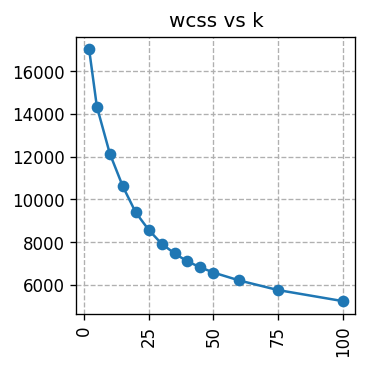

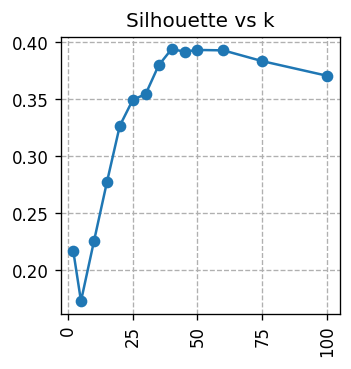

In [10]:
# plto WCSS & Silhouette to gauge at best K
plot_clust_metric(df_results,"wcss")
plot_clust_metric(df_results,"Silhouette")

In [11]:

def eval_dis_clusters(y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1,3,5]) -> pd.DataFrame:
    results = []

    for ic_thr in [1.0, 0.8, 0.6, 0.396]:

        # Build multilabel ground truth under this IC threshold
        y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

        # AUROC & AP (correct order)
        auroc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        random = y_true.sum() / y_true.size
        # top-k precision & recall
        prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
        recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

        # all-top-score precision & recall
        prec_top = get_precision_at_top_score(y_pred, y_true)
        recall_top = get_recall_at_top_score(y_pred, y_true)
        size_clust = [sum(y==max(y)) for y in y_pred]
        results.append({
            "ic_thr": ic_thr,
            "AUROC": auroc,
            "AP": ap,
            "random": random,
            **prec_k,
            **recall_k,
            "Prec@TopClust": prec_top,
            "Recall@TopClust": recall_top,
            "Size@TopClust":f"{np.mean(size_clust)}±{np.std(size_clust)}"
        })

    return pd.DataFrame(results)

In [16]:
def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
    n_samples = len(cluster_scores)
    n_diseases = len(dis_ord)

    # idx of disease corresponds to dis_ord
    dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))
    for i in range(n_samples):
        for j in clust_ord: # loop through different cluster orders
            _dis = clust_to_dis.get(j, [])
            !# CHANGE later
            # _dis_idxs = [dis_to_idx[k] for k in _dis]
            _dis_idxs = [dis_to_idx[k] for k in _dis if k in dis_to_idx.keys()]
            y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
    return y_pred

In [39]:
dis_ord = list(df_test["doid_id"].unique())

_k_candidates = list(range(35,55))
# _k_candidates = [35, 50, 60]

i = 0
for k in tqdm(_k_candidates):
    print("Clustering")
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing
        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)

    # enrichment analysis of crun_hypergeom_enrichmentluster labels!
    _df_enrich = run_hypergeom_enrichment(km.labels_, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))

    # filter significant enrichments
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    # Create a map: {cluster_id: [list of enriched disease_doids]}
    clust_to_dis = dict()
    for cluster_id in np.unique(_df_enrich_sig["cluster"]):
        # Collect all disease DOIDs that are significantly enriched in this cluster
        diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cluster_id]["disease"].to_list()
        clust_to_dis[int(cluster_id)] = diseases

    # get cluster centroids
    clust_ord = np.sort(np.unique(km.labels_))
    _centroids = get_clust_centroids(e_train, km.labels_, clust_ord )

    # Get similarity scores for the test set
    test_centr_sim = cosine_similarity(e_test, _centroids)

    # generate multilabel predictio ns from cluster scores
    test_scores = get_multilab_pred_fast(
        test_centr_sim, 
        clust_to_dis, 
        dis_ord,
        clust_ord
    )

    # we could apply softmax - to treat it as a probability
    # test_scores = softmax(test_scores, axis=1)
    test_scores = (test_scores + 1) / 2
    test_scores = test_scores / (test_scores.sum(axis=1, keepdims=True) + 1e-12)


    # evaluate multilabel predictions
    df_k_test_i = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    df_k_test_i.insert(0, "k", k)
    if i == 0:
        df_k_test = df_k_test_i.copy()
        i += 1
    else:
        df_k_test = pd.concat([df_k_test, df_k_test_i], axis=0)

  0%|          | 0/20 [00:00<?, ?it/s]

Clustering
Enrichment
Get Centroids
Get Similarity
Get Label Prediction
Evaluate Clusters
(5683, 19) 206 4 1.0
(5683, 19) 206 4 0.8
(5683, 19) 206 4 0.6
(5683, 19) 206 4 0.396


  5%|▌         | 1/20 [00:22<07:08, 22.57s/it]

Clustering
Enrichment
Get Centroids
Get Similarity
Get Label Prediction
Evaluate Clusters
(5683, 19) 206 4 1.0
(5683, 19) 206 4 0.8
(5683, 19) 206 4 0.6
(5683, 19) 206 4 0.396


 10%|█         | 2/20 [00:46<07:03, 23.51s/it]

...

 90%|█████████ | 18/20 [08:26<01:08, 34.30s/it]

Clustering
Enrichment
Get Centroids
Get Similarity
Get Label Prediction
Evaluate Clusters
(5683, 19) 206 4 1.0
(5683, 19) 206 4 0.8
(5683, 19) 206 4 0.6
(5683, 19) 206 4 0.396


 95%|█████████▌| 19/20 [08:58<00:33, 33.58s/it]

Clustering
Enrichment
Get Centroids
Get Similarity
Get Label Prediction
Evaluate Clusters
(5683, 19) 206 4 1.0
(5683, 19) 206 4 0.8
(5683, 19) 206 4 0.6
(5683, 19) 206 4 0.396


100%|██████████| 20/20 [09:28<00:00, 28.44s/it]


In [43]:
df_k_test.query("ic_thr == 1.0")

,k,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,35,1.0,0.771075,0.087066,0.004854,0.038888,0.046337,0.040964,0.038888,0.139011,0.204821,0.048423,0.433222,14.066866091852894±8.58099040026016
0,36,1.0,0.759270,0.085984,0.004854,0.044871,0.053727,0.046102,0.044871,0.161182,0.230512,0.053417,0.427063,12.279957768784094±7.061624961977136
0,37,1.0,0.756530,0.087999,0.004854,0.045223,0.049211,0.046419,0.045223,0.147633,0.232096,0.053469,0.430934,12.80274502903396±7.8553914791554345
0,38,1.0,0.756877,0.087836,0.004854,0.065634,0.051851,0.047053,0.065634,0.155552,0.235263,0.052295,0.419321,12.59809959528418±7.035418045108639
0,39,1.0,0.774736,0.090389,0.004854,0.058772,0.055839,0.052648,0.058772,0.167517,0.263241,0.060808,0.442548,11.471933837761746±6.51654013608923
0,40,1.0,0.754866,0.096190,0.004854,0.056308,0.049270,0.045399,0.056308,0.147809,0.226993,0.059500,0.430758,11.994017244413161±6.9971437397643514
0,41,1.0,0.755700,0.100534,0.004854,0.044871,0.051323,0.046806,0.044871,0.153968,0.234031,0.059799,0.444308,11.618863276438502±6.971706448718484
0,42,1.0,0.769192,0.093087,0.004854,0.047334,0.044636,0.044589,0.047334,0.133908,0.222946,0.053430,0.419321,11.599155375681859±6.193473941949841
0,43,1.0,0.762788,0.092707,0.004854,0.042759,0.051909,0.046841,0.042759,0.155728,0.234207,0.054168,0.429351,11.256730600035192±6.314091478380046
0,44,1.0,0.761066,0.090873,0.004854,0.062819,0.056191,0.049586,0.062819,0.168573,0.247932,0.059669,0.414570,11.206053140946683±6.9285805317107405


In [ ]:

# def eval_dis_clusters(y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1,3,5]) -> pd.DataFrame:
#     results = []

#     for ic_thr in [1.0, 0.8, 0.6, 0.396]:
#         print(df_split.shape, len(dis_ord), len(rel_map), ic_thr)
#         # Build multilabel ground truth under this IC threshold
#         y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

#         # AUROC & AP (correct order)
#         auroc = roc_auc_score(y_true, y_pred)
#         ap = average_precision_score(y_true, y_pred)
#         random = y_true.sum() / y_true.size
#         # top-k precision & recall
#         prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
#         recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

#         # all-top-score precision & recall
#         prec_top = get_precision_at_top_score(y_pred, y_true)
#         recall_top = get_recall_at_top_score(y_pred, y_true)
#         size_clust = [sum(y==max(y)) for y in y_pred]
#         results.append({
#             "ic_thr": ic_thr,
#             "AUROC": auroc,
#             "AP": ap,
#             "random": random,
#             **prec_k,
#             **recall_k,
#             "Prec@TopClust": prec_top,
#             "Recall@TopClust": recall_top,
#             "Size@TopClust":f"{np.mean(size_clust)}±{np.std(size_clust)}"
#         })

#     return pd.DataFrame(results)

# eval_dis_clusters(
#         test_scores,
#         df_test,
#         list(df_test["doid_id"].unique()),
#         rel_map,
#         eval_k=[1,3,5]
#     )

(5683, 19) 206 4 1.0
(5683, 19) 206 4 0.8
(5683, 19) 206 4 0.6
(5683, 19) 206 4 0.396


,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,1.000,0.771075,0.087066,0.004854,0.038888,0.046337,0.040964,0.038888,0.139011,0.204821,0.048423,0.433222,14.066866091852894±8.58099040026016
1,0.800,0.773397,0.155500,0.010990,0.110505,0.117895,0.110259,0.040134,0.140873,0.217837,0.119742,0.444692,14.066866091852894±8.58099040026016
2,0.600,0.756788,0.238253,0.037965,0.290164,0.268931,0.253986,0.042862,0.120646,0.180562,0.258770,0.371225,14.066866091852894±8.58099040026016
3,0.396,0.705712,0.361395,0.151883,0.489882,0.469705,0.461130,0.017820,0.051035,0.082498,0.456364,0.186092,14.066866091852894±8.58099040026016


In [ ]:
# def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
#     n_samples = len(cluster_scores)
#     n_diseases = len(dis_ord)

#     # idx of disease corresponds to dis_ord
#     dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

#     y_pred = np.zeros((n_samples, n_diseases))
#     for i in range(n_samples):
#         for j in clust_ord: # loop through different cluster orders
#             _dis = clust_to_dis.get(j, [])
#             !# CHANGE later
#             # _dis_idxs = [dis_to_idx[k] for k in _dis]
#             _dis_idxs = [dis_to_idx[k] for k in _dis if k in _dis]
#             y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
#     return y_pred

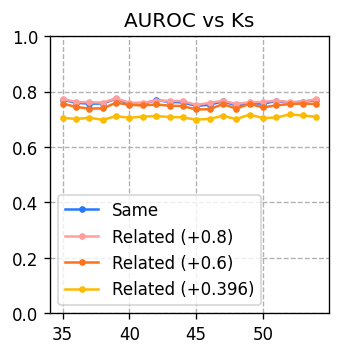

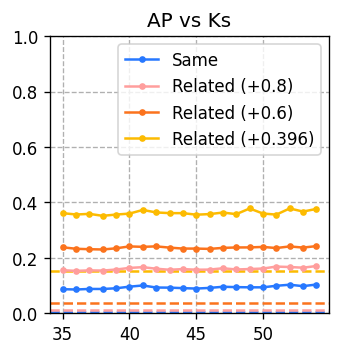

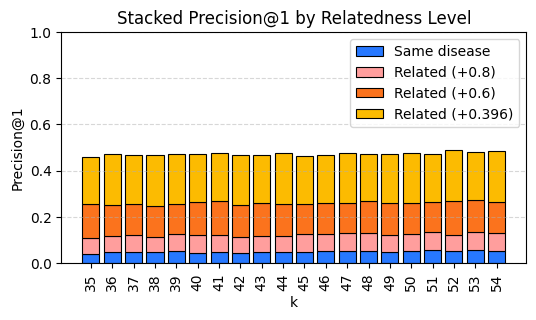

In [41]:
# plot performance
plot_clust_dis_perf(df_k_test, "AUROC")
plot_clust_dis_perf(df_k_test, "AP", random=True)
plot_stacked_p1(df_k_test, metric="Prec@5")


In [ ]:
# get cluster labels and performance for best k
k = 53
do_cosine_dist = True
km = KMeans(n_clusters=k, n_init=20, random_state=42)
if do_cosine_dist:
    from sklearn import preprocessing
    km.fit(preprocessing.normalize(e_train))
else:
    km.fit(e_train)
k_labels = km.labels_
df_k_best = df_k_test.query("k==@k")

df_k_1 = get_df_results_clean(df_k_best, ["AUROC", "AP", "random"])
df_k_2 = get_df_results_clean(df_k_best, ["Prec@1", "Prec@3", "Prec@5"])


NameError: name 'df_k_test' is not defined

In [56]:
# get cluster labels and performance for best k
k = 53
do_cosine_dist = True
km = KMeans(n_clusters=k, n_init=20, random_state=42)
if do_cosine_dist:
    from sklearn import preprocessing
    km.fit(preprocessing.normalize(e_train))
else:
    km.fit(e_train)

In [57]:
km.predict(e_train)

array([29,  8,  2, ..., 21, 49, 47], dtype=int32)

In [50]:
df_k_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.064,0.194,0.279,0.159,0.149,0.134,0.298,0.293,0.272,0.505,0.500,0.480


In [48]:
df_k_res = pd.DataFrame([{"Nº Clusters":len(set(k_labels)),
                         "Max Cluster Size":max(Counter(k_labels).values()),
                         "Silhouette":silhouette_score(e_train,k_labels.astype(int), metric="cosine"),
                         }])
df_k_res

,Nº Clusters,Max Cluster Size,Silhouette
0,53,1489,0.39582


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


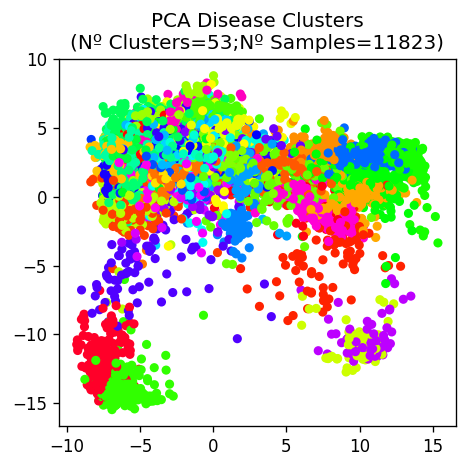

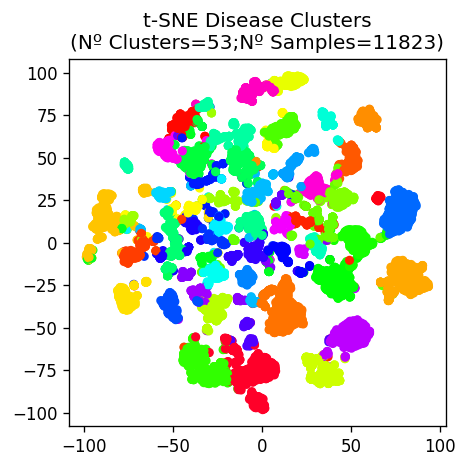

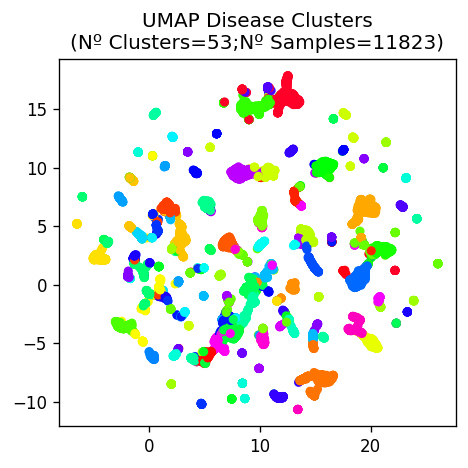

In [13]:
# Compute PCA
pca = PCA(n_components=2, random_state=42)
pca_emb = pca.fit_transform(e_train)   # shape: (n_samples, 2)

tsne = TSNE(n_components=2, random_state=42)
tsne_emb = tsne.fit_transform(e_train)

umap = UMAP(n_components=2, random_state=42)
umap_emb = umap.fit_transform(e_train)

plot_reduced_emb(pca_emb, k_labels, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(k_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, k_labels, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(k_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, k_labels, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(k_labels))};Nº Samples={len(e_train)})")


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


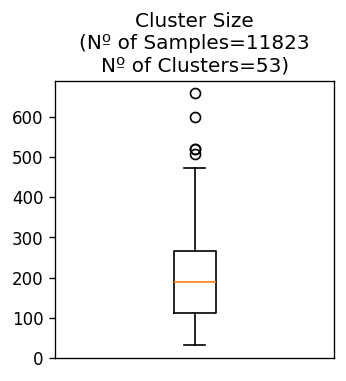

In [14]:
plot_nclusters(k_labels)

### 3.2 Hierarchical Clustering

In [13]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from tqdm import tqdm

hc_metric = "cosine"
Z = linkage(pdist(e_train, metric=hc_metric), method="average")


In [14]:

_h_candidates = np.linspace(0.05, 1, 50)   # adjust range if needed
results = list()
for h in tqdm(_h_candidates):   # <<< minimal change: iterate over thresholds    
    # generate labels
    preds = fcluster(Z, t=h, criterion="distance") - 1  # remove 1 because f-cluster returns labels from 1-N
    k = len(np.unique(preds))

    if k == 1:
        break

    # evaluate
    _results_i = evaluate_clusters(preds, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "h": h})
    results.append(_results_i)

df_results = pd.DataFrame(results)

 72%|███████▏  | 36/50 [00:45<00:17,  1.27s/it]


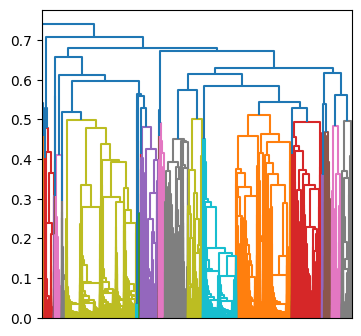

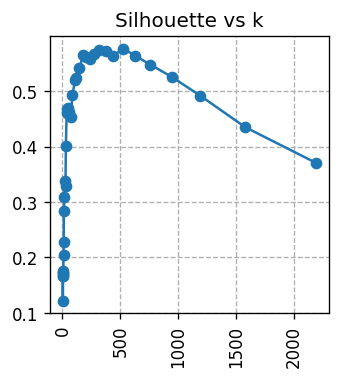

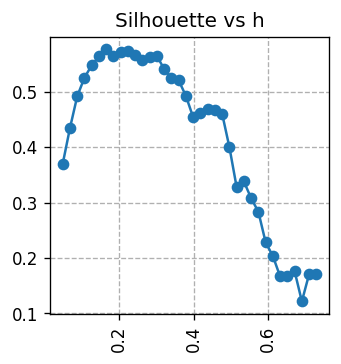

In [16]:
# plot dendrogram & Silhouette to gauge at best K
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram

# exploratory plots - dendrogram
plt.figure(figsize=(4,4))
dendrogram(Z, labels=["" for _ in range(len(df_train))])
plt.show()

plot_clust_metric(df_results,"Silhouette")
plot_clust_metric(df_results,"Silhouette", x_lab="h")

In [25]:
ALPHA = 0.05
_h_candidates = np.linspace(0.15, 0.45, 20)   # adjust range if needed
# results = list()
i = 0
dis_ord = list(df_test["doid_id"].unique())
for h in tqdm(_h_candidates):   # <<< minimal change: iterate over thresholds
    
    # generate labels
    preds = fcluster(Z, t=h, criterion="distance") - 1  # remove 1 because f-cluster returns labels from 1-N
    k = len(np.unique(preds))

    if k == 1:
        break
    
    # enrichment
    _df_enrich = run_hypergeom_enrichment(preds, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    clust_to_dis = {}
    for cid in np.unique(_df_enrich_sig["cluster"]):
        diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
        clust_to_dis[int(cid)] = diseases

    clust_ord = np.sort(np.unique(preds))
    _centroids = get_clust_centroids(e_train, preds, clust_ord)

    # get similarity scores
    test_centr_sim = cosine_similarity(e_test, _centroids)

    test_scores = get_multilab_pred_fast(
        test_centr_sim,
        clust_to_dis,
        dis_ord,
        clust_ord
    )

    test_scores = softmax(test_scores, axis=1)

    df_hc_test_i = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    df_hc_test_i.insert(0, "k", k)
    df_hc_test_i.insert(1, "h", h)

    if i == 0:
        df_hc_test = df_hc_test_i.copy()
        i += 1
    else:
        df_hc_test = pd.concat([df_hc_test, df_hc_test_i], axis=0)


100%|██████████| 20/20 [01:32<00:00,  4.62s/it]


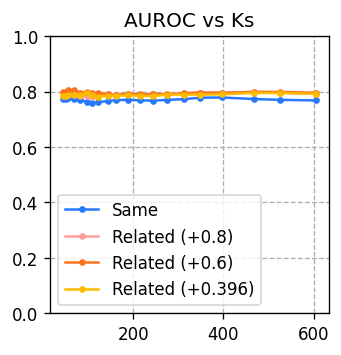

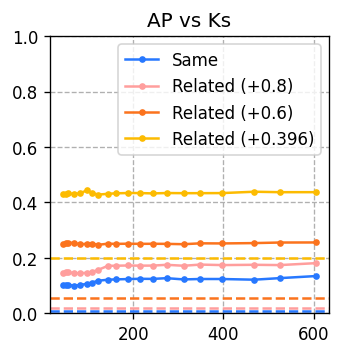

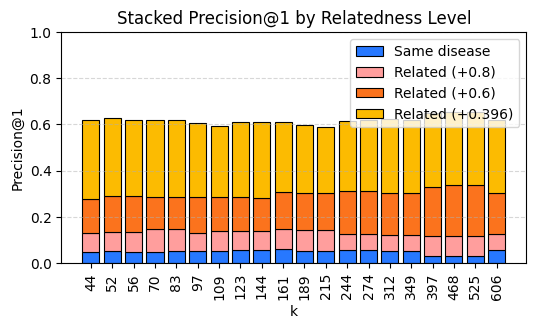

In [26]:
# plot performance
plot_clust_dis_perf(df_hc_test, "AUROC")
plot_clust_dis_perf(df_hc_test, "AP", random=True)
plot_stacked_p1(df_hc_test, metric="Prec@5")


In [21]:
df_k_best

,k,h,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust


In [23]:
df_hc_test

,k,h,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,1029,0.100000,1.000,0.767673,0.140977,0.008130,0.063417,0.045509,0.046635,0.063417,0.136527,0.233176,0.067156,0.090557,1.6289116588202714±0.8702507497486865
1,1029,0.100000,0.800,0.790699,0.186029,0.019054,0.211299,0.157113,0.128662,0.091041,0.194249,0.269778,0.208951,0.115319,1.6289116588202714±0.8702507497486865
2,1029,0.100000,0.600,0.795225,0.255321,0.054900,0.389643,0.305548,0.281806,0.065593,0.155304,0.225098,0.367333,0.093725,1.6289116588202714±0.8702507497486865
3,1029,0.100000,0.396,0.788636,0.434660,0.199877,0.670728,0.640266,0.620770,0.032685,0.089335,0.140517,0.674772,0.051101,1.6289116588202714±0.8702507497486865
0,920,0.110526,1.000,0.765745,0.138296,0.008130,0.064248,0.044863,0.047023,0.064248,0.134589,0.235115,0.067594,0.092218,1.6654666297424536±0.8871343702914094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,194,0.289474,0.396,0.785595,0.433620,0.199877,0.648574,0.604542,0.611631,0.032204,0.086989,0.142836,0.647464,0.102283,3.1822209914151203±1.718495231878989
0,179,0.300000,1.000,0.770142,0.124018,0.008130,0.052340,0.053448,0.060150,0.052340,0.160343,0.300748,0.055580,0.166713,3.2486845749099973±1.7015380056078853
1,179,0.300000,0.800,0.791789,0.173561,0.019054,0.166990,0.171328,0.150762,0.076364,0.242214,0.339195,0.174058,0.268785,3.2486845749099973±1.7015380056078853
2,179,0.300000,0.600,0.791032,0.251016,0.054900,0.338964,0.349857,0.309443,0.056479,0.171462,0.247269,0.340335,0.192514,3.2486845749099973±1.7015380056078853


In [27]:
best_k = 56

if best_k == None:
    df_hc_test.max()
df_k_best = df_hc_test.query("k==@best_k")
_h = df_hc_test["h"].values[0]

hc_labels = fcluster(Z, t=_h, criterion="distance") - 1  # remove 1 because f-cluster returns labels from 1-N

df_hc_1 = get_df_results_clean(df_k_best, ["AUROC", "AP", "random"])
df_hc_2 = get_df_results_clean(df_k_best, ["Prec@1", "Prec@3", "Prec@5"])


In [39]:
df_hc_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.052,0.127,0.194,0.100,0.105,0.097,0.254,0.248,0.249,0.450,0.454,0.456


In [37]:
df_hc_res = pd.DataFrame([{"Nº Clusters":len(set(hc_labels)),
                         "Max Cluster Size":max(Counter(hc_labels).values()),
                         "Silhouette":silhouette_score(e_train,hc_labels.astype(int), metric="cosine"),
                         }])

In [38]:
df_hc_res

,Nº Clusters,Max Cluster Size,Silhouette
0,137,4903,0.29516


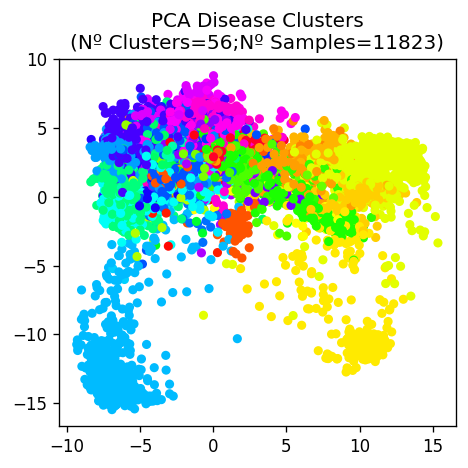

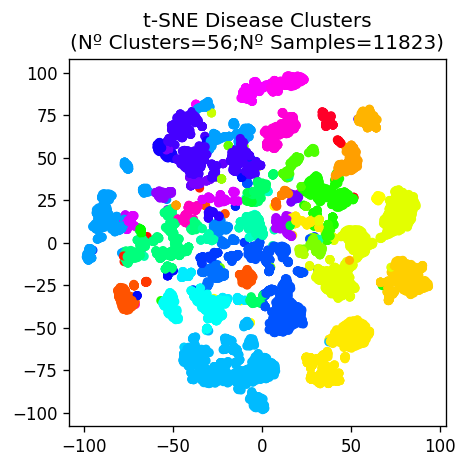

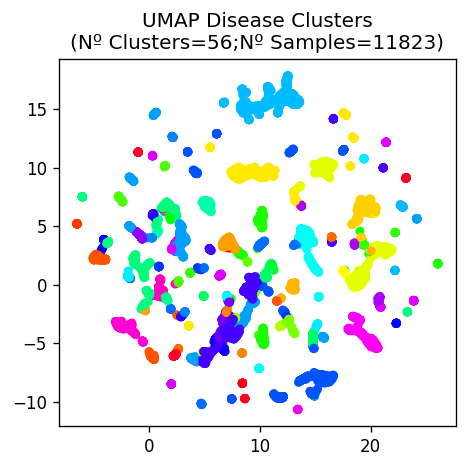

In [20]:
# Compute PCA
plot_reduced_emb(pca_emb, hc_labels, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(hc_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, hc_labels, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(hc_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, hc_labels, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(hc_labels))};Nº Samples={len(e_train)})")


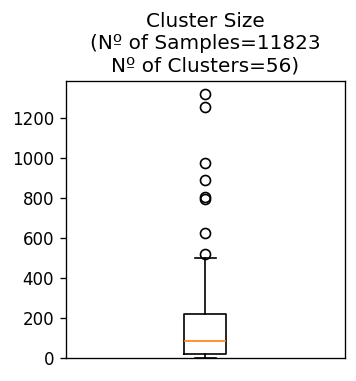

In [21]:
# nº of clusters
plot_nclusters(hc_labels)

### 3.3 HDBSCAN

In [ ]:
from hdbscan import HDBSCAN
from scipy.spatial.distance import pdist, squareform

_min_cluster_sizes = [5, 10, 15, 20] 
_min_samples = [1, 5]

cosine_train = squareform(pdist(e_train, metric="cosine"))

results = list()
i = 0
for mcs in tqdm(_min_cluster_sizes):
    for ms in _min_samples:

        hdbscan_clust = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="precomputed")
        hdbscan_clust = hdbscan_clust.fit(cosine_train)
        preds = hdbscan_clust.labels_
        preds_no_noise = preds[preds >= 0]
        k = len(np.unique(preds_no_noise))

        # hdbscan unique metric
        persistence = hdbscan_clust.cluster_persistence_

        if k <= 1:
            continue

        # remove noise
        mask_noise = (preds == -1)
        _results_i = evaluate_clusters(preds[~mask_noise], df_train[~mask_noise]["doid_id"].values, e_train[~mask_noise])
        _results_i.update({
            "k": k,
            "min_cluster_size": mcs,
            "min_samples": ms,
            "mean_persistence": persistence.mean(),
            "max_persistence": persistence.max(),
            "sum_persistence": persistence.sum()
        })
        results.append(_results_i)

df_results = pd.DataFrame(results)



100%|██████████| 4/4 [00:23<00:00,  5.91s/it]


In [71]:
mask_noise = (preds == -1)
_results_i = evaluate_clusters(preds[~mask_noise], df_train[~mask_noise]["doid_id"].values, e_train[~mask_noise])

In [72]:
_results_i

{'Silhouette': 0.5712262843629519,
 'CH': 1204.9212878556777,
 'DB': 1.0818398917325294,
 'Purity': 0.8260631502098923,
 'NMI': 0.8833335484358191,
 'ARI': 0.7010350178883519,
 'AMI': 0.875815239036947}

In [30]:
for mcs in tqdm([5, 10, 15, 20] ):
    for ms in [1,5]:

        hdbscan_clust = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="precomputed")
        hdbscan_clust = hdbscan_clust.fit(cosine_train)
        preds = hdbscan_clust.labels_
        preds_no_noise = preds[preds >= 0]
        k = len(np.unique(preds_no_noise))

        # hdbscan unique metric
        persistence = hdbscan_clust.cluster_persistence_

        if k <= 1:
            continue

        _results_i = evaluate_clusters(preds, df_train["doid_id"].values, e_train)
        _results_i.update({
            "k": k,
            "min_cluster_size": mcs,
            "min_samples": ms,
            "mean_persistence": persistence.mean(),
            "max_persistence": persistence.max(),
            "sum_persistence": persistence.sum()
        })
        results.append(_results_i)

df_results = pd.DataFrame(results)

100%|██████████| 4/4 [00:27<00:00,  6.97s/it]


In [31]:
df_results

,Silhouette,CH,DB,Purity,NMI,ARI,AMI,k,min_cluster_size,min_samples,mean_persistence,max_persistence,sum_persistence
0,0.518330,293.933244,0.999979,0.921558,0.834626,0.624538,0.799362,385,5,1,0.019940,0.729994,7.677028
1,0.552446,374.124851,0.846148,0.914352,0.871056,0.787632,0.851316,226,5,5,0.033946,0.702585,7.671686
2,0.579057,431.025028,1.052732,0.890410,0.853061,0.667510,0.831854,190,10,1,0.050118,0.529130,9.522409
3,0.657946,531.872961,0.937072,0.893085,0.868525,0.714825,0.851805,150,10,5,0.048754,0.401712,7.313105
4,0.618964,530.334646,1.053213,0.877092,0.856166,0.678577,0.839011,139,15,1,0.053395,0.455775,7.421840
5,0.598495,609.197588,0.982998,0.888778,0.879055,0.813862,0.866905,113,15,5,0.054298,0.481586,6.135630
6,0.622737,650.073797,1.087271,0.861971,0.859267,0.689549,0.845979,99,20,1,0.060678,0.490913,6.007107
7,0.605494,715.919059,1.042787,0.863988,0.877092,0.818444,0.867070,83,20,5,0.058565,0.468215,4.860884
8,0.262257,90.773340,1.296092,0.780343,0.723807,0.270528,0.673509,385,5,1,0.019940,0.729994,7.677028
9,0.233734,117.327789,1.285123,0.712932,0.716524,0.278841,0.679480,226,5,5,0.033946,0.702585,7.671686


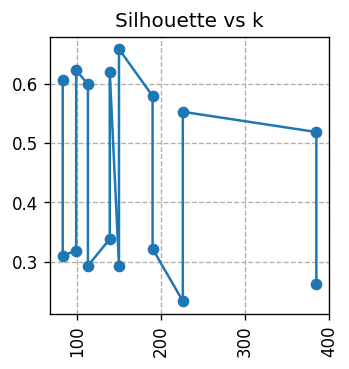

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


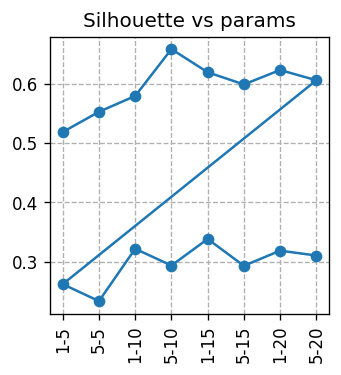

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


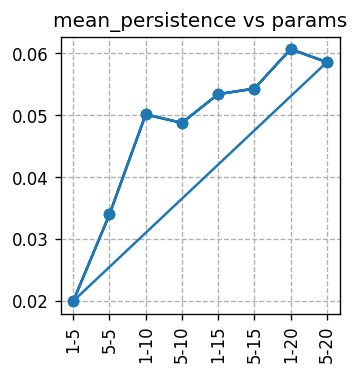

In [40]:
df_results["params"] = [f"{i}-{j}" for i,j in zip(df_results["min_samples"],df_results["min_cluster_size"])]
df_r_sort = df_results.sort_values("k")
plot_clust_metric(df_r_sort,"Silhouette")
plot_clust_metric(df_results,"Silhouette", x_lab="params")
plot_clust_metric(df_results,"mean_persistence", x_lab="params")


In [38]:
from hdbscan import HDBSCAN

_min_cluster_sizes = [5, 10, 20]
_min_samples = [5, 10]

results = list()
i = 0
for mcs in tqdm(_min_cluster_sizes):
    for ms in _min_samples:

        hdbscan_clust = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="precomputed")
        hdbscan_clust = hdbscan_clust.fit(cosine_train)
        preds = hdbscan_clust.labels_
        preds_no_noise = preds[preds >= 0]
        k = len(np.unique(preds_no_noise))

        if k <= 1:
            continue

        _results_i = evaluate_clusters(preds, df_train["doid_id"].values, e_train)
        _results_i.update({"k": k, "min_cluster_size": mcs, "min_samples": ms})
        results.append(_results_i)

        _df_enrich = run_hypergeom_enrichment(preds, df_train["doid_id"].astype(str).to_numpy())
        _df_enrich = _df_enrich.copy()
        _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
        _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

        clust_to_dis = {}
        for cid in np.unique(_df_enrich_sig["cluster"]):
            if cid == -1:
                continue
            diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
            clust_to_dis[int(cid)] = diseases

        clust_ord = np.sort(np.unique(preds))
        clust_ord = clust_ord[clust_ord >= 0]
        _centroids = get_clust_centroids(e_train, preds, clust_ord)

        test_centr_sim = cosine_similarity(e_test, _centroids)

        test_scores = get_multilab_pred_fast(
            test_centr_sim,
            clust_to_dis,
            dis_ord,
            clust_ord
        )

        test_scores = softmax(test_scores, axis=1)

        df_hd_test_i = eval_dis_clusters(
            test_scores,
            df_test,
            dis_ord,
            rel_map,
            eval_k=[1,3,5]
        )
        df_hd_test_i.insert(0, "k", k)
        df_hd_test_i.insert(1, "min_cluster_size", mcs)
        df_hd_test_i.insert(2, "min_samples", ms)

        if i == 0:
            df_hd_test = df_hd_test_i.copy()
            i += 1
        else:
            df_hd_test = pd.concat([df_hd_test, df_hd_test_i], axis=0)


100%|██████████| 3/3 [00:42<00:00, 14.24s/it]


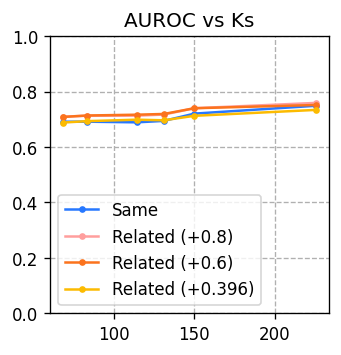

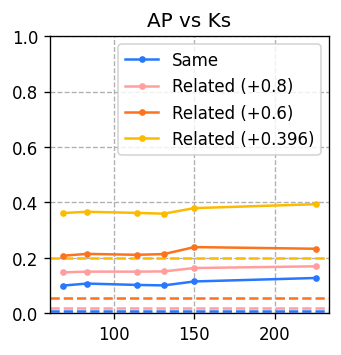

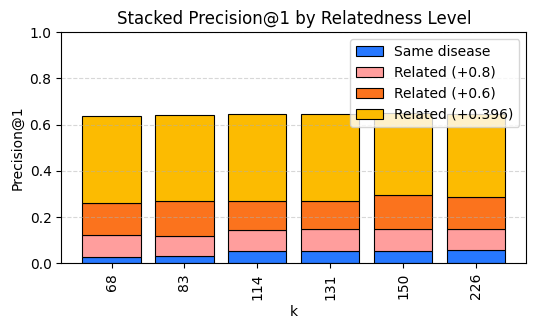

In [39]:
# plot performance
df_hd_test_sort = df_hd_test.sort_values(by=["k","AP"], ascending=[True,False])
df_hd_test_sort.drop_duplicates(["k","ic_thr"], inplace=True, keep="first")
plot_clust_dis_perf(df_hd_test_sort, "AUROC")
plot_clust_dis_perf(df_hd_test_sort, "AP", random=True)
plot_stacked_p1(df_hd_test_sort, metric="Prec@5")

In [42]:
best_k = 68

df_hd_best = df_hd_test_sort.query(f"k == @best_k")
_min_clust = df_hd_best["min_cluster_size"].values[0]
_min_samp = df_hd_best["min_samples"].values[0]

hdbscan_clust = HDBSCAN(min_cluster_size=_min_clust, min_samples=_min_samp, metric="precomputed")
hdbscan_clust = hdbscan_clust.fit(cosine_train)
hd_labels = hdbscan_clust.labels_
mask_noise = hd_labels == -1

_df_enrich = run_hypergeom_enrichment(hd_labels, df_train["doid_id"].astype(str).to_numpy())
_df_enrich = _df_enrich.copy()
_df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
_df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

clust_to_dis = {}
for cid in np.unique(_df_enrich_sig["cluster"]):
    if cid == -1:
        continue
    diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
    clust_to_dis[int(cid)] = diseases

clust_ord = np.sort(np.unique(preds))
clust_ord = clust_ord[clust_ord >= 0]
_centroids = get_clust_centroids(e_train, preds, clust_ord)

test_centr_sim = cosine_similarity(e_test, _centroids)

test_hd_scores = get_multilab_pred_fast(
    test_centr_sim,
    clust_to_dis,
    dis_ord,
    clust_ord
)

test_hd_scores = softmax(test_hd_scores, axis=1)

df_hd_1 = get_df_results_clean(df_hd_best, ["AUROC", "AP", "random"])
df_hd_2 = get_df_results_clean(df_hd_best, ["Prec@1", "Prec@3", "Prec@5"])

In [47]:
df_hd_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.040,0.115,0.144,0.185,0.149,0.122,0.292,0.305,0.259,0.646,0.657,0.638


In [43]:
df_hd_res = pd.DataFrame([{"Nº Clusters":len(set(hd_labels)-{-1}),
                         "Max Cluster Size":max(Counter(hd_labels[~mask_noise]).values()),
                         "Silhouette":silhouette_score(e_train[~mask_noise],hd_labels.astype(int)[~mask_noise], metric="cosine"),
                         }])

In [44]:
df_hd_res

,Nº Clusters,Max Cluster Size,Silhouette
0,68,994,0.696251


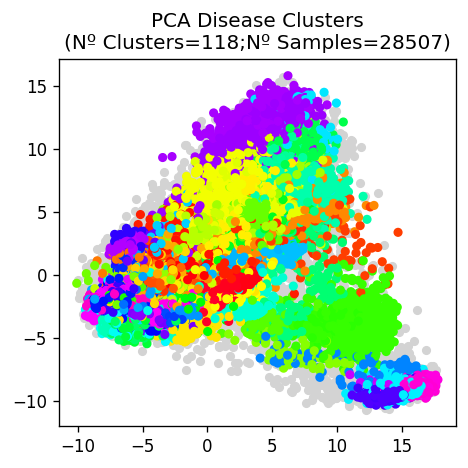

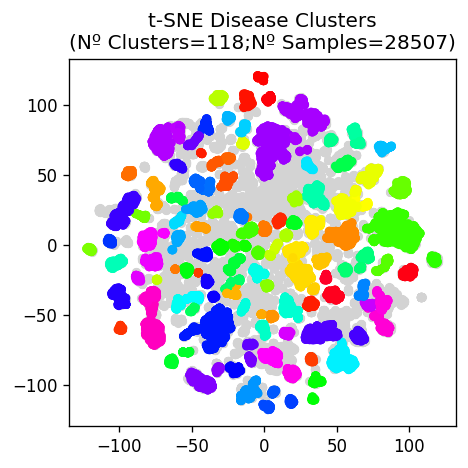

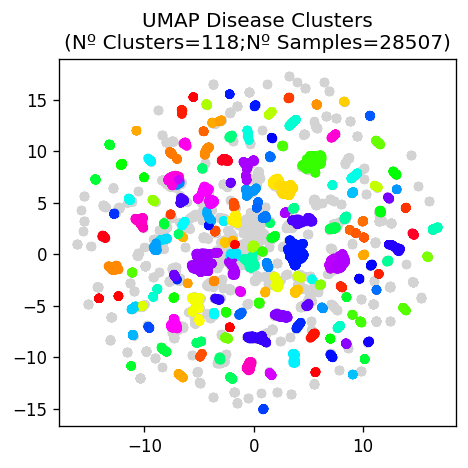

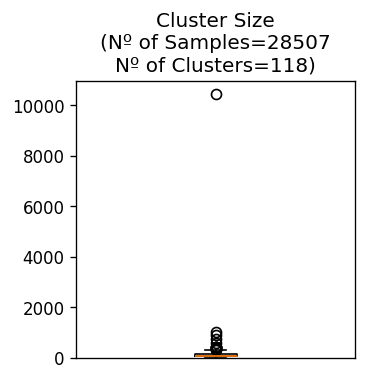

In [67]:
# Compute PCA
plot_reduced_emb(pca_emb, hd_labels, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(hd_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, hd_labels, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(hd_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, hd_labels, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(hd_labels))};Nº Samples={len(e_train)})")

# nº of clusters
plot_nclusters(hd_labels)

### 3.4 Fuzzy Clustering

#### Evaluation Plots

### 3.5 Centroids

In [107]:
results = []
i = 0

# get disease list
diseases = df_test["doid_id"].astype(str).unique()
diseases = list(sorted(diseases))   # stable ordering
dis_to_clust = {d:i for i, d in enumerate(diseases)}
clust_to_dis = {i:[d] for d, i in dis_to_clust.items()}

# train labels
c_labels = df_train["doid_id"].astype(str).map(dis_to_clust).values

# get centroids
def get_centroids(x, labels, order):
    out = []
    for c in order:
        pts = x[labels == c]
        centroid = pts.mean(axis=0)
        out.append(centroid)
    return np.array(out)

clust_ord = np.arange(len(diseases))
centroids = get_centroids(e_train, c_labels, clust_ord)

# evaluate clusters
_results_i = evaluate_clusters(c_labels, df_train["doid_id"].values, e_train)
_results_i.update({"k": len(diseases), "method": "DiseaseCentroids"})
results.append(_results_i)

# get test similarity to centroids
test_centr_sim = cosine_similarity(e_test, centroids)

# get test predictions
test_c_scores = get_multilab_pred_fast(
    test_centr_sim,
    clust_to_dis,
    diseases,     # dis_ord
    clust_ord
)

# normalize probabilities
test_c_scores = softmax(test_c_scores, axis=1)

# evaluate predictions
_df_c_test = eval_dis_clusters(
    test_c_scores,
    df_test,
    diseases,
    rel_map,
    eval_k=[1,3,5]
)

_df_c_test.insert(0, "k", len(diseases))
_df_c_test.insert(1, "method", "DiseaseCentroids")
df_c_test = _df_c_test.copy()

df_results = pd.DataFrame(results)


/tmp/ipykernel_8393/2758185152.py:171: RuntimeWarning: invalid value encountered in cast
  preds = np.asarray(preds, dtype=int)


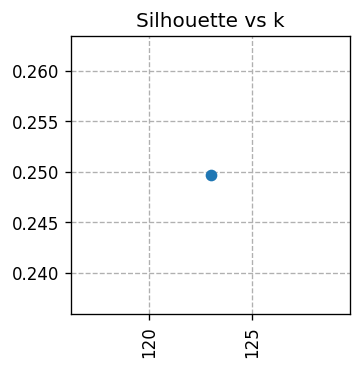

In [ ]:
plot_clust_metric(df_results,"Silhouette")


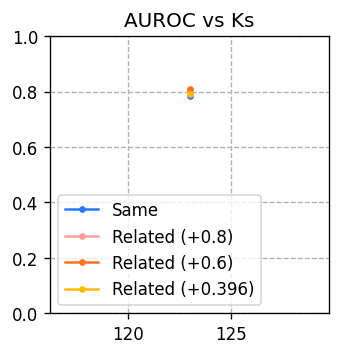

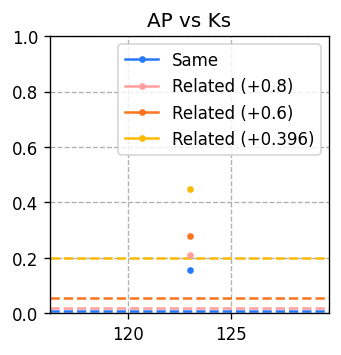

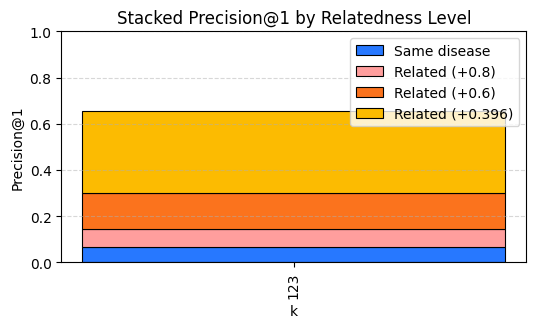

In [ ]:
plot_clust_dis_perf(df_c_test, "AUROC")
plot_clust_dis_perf(df_c_test, "AP", random=True)
plot_stacked_p1(df_c_test, metric="Prec@5")

In [81]:
df_c_1 = get_df_results_clean(df_c_test, ["AUROC", "AP", "random"])
df_c_2 = get_df_results_clean(df_c_test, ["Prec@1", "Prec@3", "Prec@5"])


In [83]:
df_c_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.245,0.349,0.395,0.331,0.212,0.154,0.435,0.359,0.316,0.564,0.538,0.519


In [78]:
df_c_res = pd.DataFrame([{"Nº Clusters":len(set(c_labels)),
                         "Max Cluster Size":max(Counter(c_labels).values()),
                         "Silhouette":silhouette_score(e_train,c_labels.astype(int), metric="cosine"),
                         }])

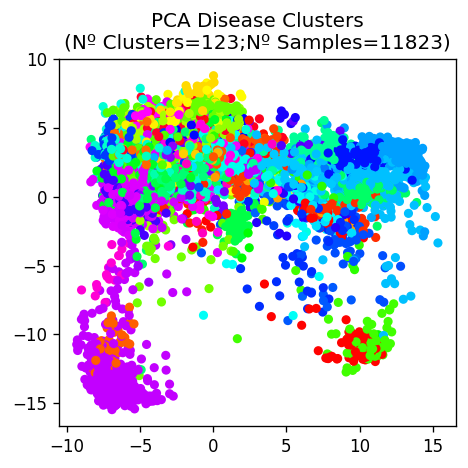

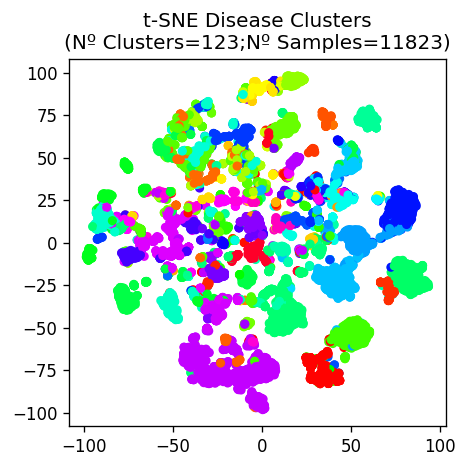

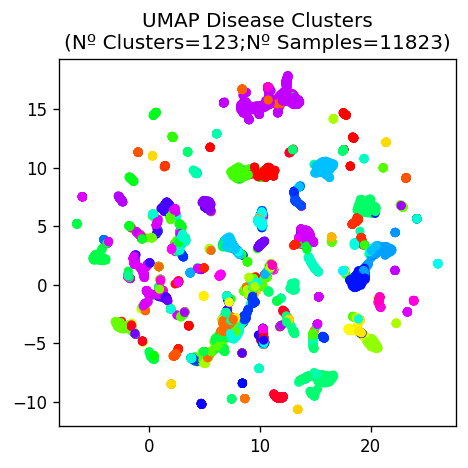

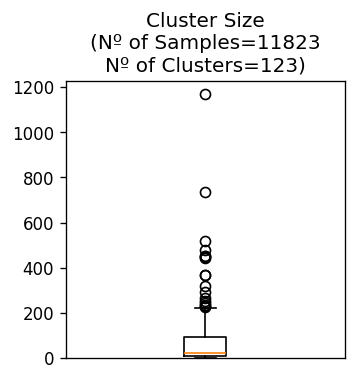

In [32]:
# Compute PCA
plot_reduced_emb(pca_emb, c_labels, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(c_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, c_labels, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(c_labels))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, c_labels, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(c_labels))};Nº Samples={len(e_train)})")

# nº of clusters
plot_nclusters(c_labels)

### 3.6 Clustering + Centroids

In [90]:
from hdbscan import HDBSCAN

min_disease_size = 20      # threshold for trying subclustering
sub_min_cluster_size = 5   # HDBSCAN parameters
sub_min_samples = 1

results = []
i = 0

# disease order
diseases = df_train["doid_id"].astype(str).unique()
diseases = list(sorted(diseases))
dis_to_clust = {d: i for i, d in enumerate(diseases)}


# initialize variables
refined_centroids = []
refined_mapping = {}      # cluster_id → [disease]
cluster_id_counter = 0

n_non_clust_dis = 0
# loop through diseases
for dis in diseases:
    idx = np.where(df_train["doid_id"].astype(str).values == dis)[0]
    emb_dis = e_train[idx]

    # If too few samples → single centroid
    if len(idx) < min_disease_size:
        centroid = emb_dis.mean(axis=0)
        refined_centroids.append(centroid)
        refined_mapping[cluster_id_counter] = [dis]
        cluster_id_counter += 1
        n_non_clust_dis +=1
        continue

    # Try subclustering inside this disease
    sub = HDBSCAN(
        min_cluster_size=sub_min_cluster_size,
        min_samples=sub_min_samples,
        metric="euclidean"
    ).fit_predict(emb_dis)

    unique_sub = np.unique(sub[sub >= 0])   # discard noise

    # No real subclusters → fallback to single centroid
    if len(unique_sub) <= 1:
        centroid = emb_dis.mean(axis=0)
        refined_centroids.append(centroid)
        refined_mapping[cluster_id_counter] = [dis]
        cluster_id_counter += 1
        n_non_clust_dis += 1
        continue

    # Multiple subclusters → centroid per subcluster
    for sc in unique_sub:
        centroid = emb_dis[sub == sc].mean(axis=0)
        refined_centroids.append(centroid)
        refined_mapping[cluster_id_counter] = [dis]
        cluster_id_counter += 1

# Convert centroids to array
refined_centroids = np.vstack(refined_centroids)
clust_ord = np.arange(len(refined_centroids))

# compute distance to centroids
train_sim = cosine_similarity(e_train, refined_centroids)
c_hd_labels = np.argmax(train_sim, axis=1)

# Evaluate clustering geometry
_results_i = evaluate_clusters(c_hd_labels, df_train["doid_id"].values, e_train)
_results_i.update({"k": len(refined_centroids), "method": "Disease+Subcentroids"})
results.append(_results_i)

# -----------------------------------------
# 4. TEST PREDICTIONS
# -----------------------------------------
test_centr_sim = cosine_similarity(e_test, refined_centroids)

test_scores = get_multilab_pred(
    test_centr_sim,
    refined_mapping,
    diseases,     # dis_ord
    clust_ord
)

test_scores = softmax(test_scores, axis=1)

df_c_hd_test = eval_dis_clusters(
    test_scores,
    df_test,
    diseases,
    rel_map,
    eval_k=[1,3,5]
)

df_c_hd_test.insert(0, "k", len(refined_centroids))
df_c_hd_test.insert(1, "method", "Disease+Subcentroids")

df_results = pd.DataFrame(results)


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/

In [39]:
print(f"Nº of non-clustered diseases {n_non_clust_dis}")

Nº of non-clustered diseases 60


In [67]:
df_c_hd_1 = get_df_results_clean(df_c_hd_test, ["AUROC", "AP", "random"])
df_c_hd_2 = get_df_results_clean(df_c_hd_test, ["Prec@1", "Prec@3", "Prec@5"])


In [91]:
df_c_hd_res = pd.DataFrame([{"Nº Clusters":len(set(c_hd_labels)),
                         "Max Cluster Size":max(Counter(c_hd_labels).values()),
                         "Silhouette":silhouette_score(e_train,c_hd_labels.astype(int), metric="cosine"),
                         }])

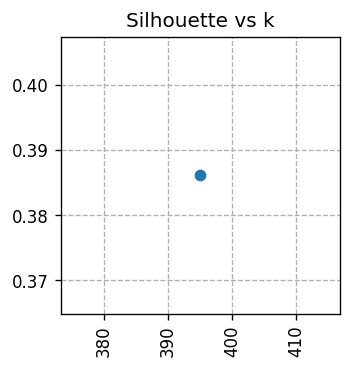

In [45]:
plot_clust_metric(df_results,"Silhouette")


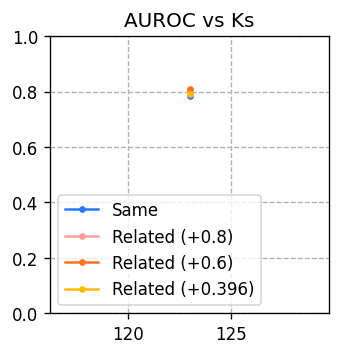

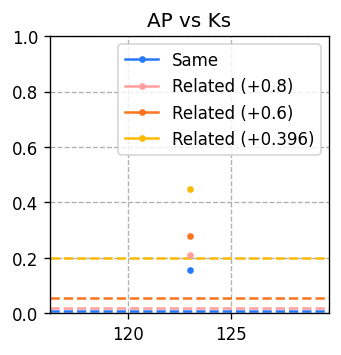

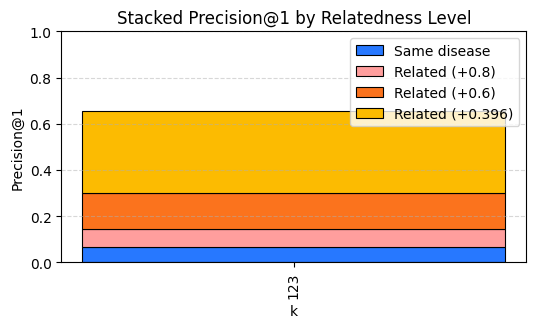

In [46]:

plot_clust_dis_perf(df_c_test, "AUROC")
plot_clust_dis_perf(df_c_test, "AP", random=True)
plot_stacked_p1(df_c_test, metric="Prec@5")

## Joint Evaluation Tables

In [107]:
df_eval_1 = pd.concat([df_k_1,df_hc_1, df_hd_1, df_c_1, df_c_hd_1])
df_eval_1["cluster_type"] = ["k","HC","HDBSCAN","Centroid","Centroid-HDBSCAN"]
df_eval_2 = pd.concat([df_k_2,df_hc_2, df_hd_2, df_c_2, df_c_hd_2])
df_eval_2["cluster_type"] = ["k","HC","HDBSCAN","Centroid","Centroid-HDBSCAN"]
df_res = pd.concat([df_k_res,df_hc_res, df_hd_res, df_c_res, df_c_hd_res])
df_res["cluster_type"] = ["k","HC","HDBSCAN","Centroid","Centroid-HDBSCAN"]
df_res["Silhouette"] = df_res["Silhouette"].apply(lambda x: f"{x:.3f}")

In [110]:
df_eval_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5,cluster_type
0,0.031,0.111,0.266,0.117,0.112,0.115,0.232,0.270,0.261,0.660,0.640,0.605,k
0,0.031,0.105,0.146,0.077,0.100,0.115,0.259,0.307,0.321,0.647,0.656,0.657,HC
0,0.033,0.110,0.148,0.168,0.136,0.118,0.340,0.294,0.282,0.645,0.643,0.630,HDBSCAN
0,0.081,0.177,0.336,0.225,0.157,0.145,0.392,0.315,0.299,0.708,0.685,0.653,Centroid
0,0.073,0.134,0.298,0.213,0.152,0.140,0.363,0.298,0.299,0.695,0.668,0.646,Centroid-HDBSCAN


In [111]:
df_res

,Nº Clusters,Max Cluster Size,Silhouette,cluster_type
0,53,658,0.536,k
0,56,1318,0.462,HC
0,68,2683,0.374,HDBSCAN
0,123,1170,0.250,Centroid
0,394,839,0.386,Centroid-HDBSCAN


# Junkyard

In [ ]:
for k in tqdm(_k_candidates):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing
        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)
    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)

    # enrichment analysis of crun_hypergeom_enrichmentluster labels!
    _df_enrich = run_hypergeom_enrichment(km.labels_, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))

    # filter significant enrichments
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    # Create a map: {cluster_id: [list of enriched disease_doids]}
    clust_to_dis = dict()
    for cluster_id in np.unique(_df_enrich_sig["cluster"]):
        # Collect all disease DOIDs that are significantly enriched in this cluster
        diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cluster_id]["disease"].to_list()
        clust_to_dis[int(cluster_id)] = diseases

    def get_clust_centroids(x, labels, label_ord):
        centroids = list()
        for l in label_ord:
            mask = labels == l
            points = x[mask]
            centroid = np.mean(points, axis=0)
            centroids.append(centroid)
        return np.array(centroids)

    # get cluster centroids
    clust_ord = np.sort(np.unique(km.labels_))
    _centroids = get_clust_centroids(e_train, km.labels_, clust_ord )

    # Get similarity scores for the test set
    test_centr_sim = cosine_similarity(e_test, _centroids)

    # generate multilabel predictio ns from cluster scores
    test_scores = get_multilab_pred(
        test_centr_sim, 
        clust_to_dis, 
        dis_ord,
        clust_ord
    )

    # we could apply softmax - to treat it as a probability
    test_scores = softmax(test_scores, axis=1)

    # evaluate multilabel predictions
    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    _df_test_eval.insert(0, "k", k)
    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)
    
df_results = pd.DataFrame(results)


In [143]:
_df_test_eval

,k,method,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,123,DiseaseCentroids,1.000,0.782932,0.157955,0.008130,0.080864,0.058986,0.067294,0.080864,0.176959,0.336472,0.080864,0.080864,1.0±0.0
1,123,DiseaseCentroids,0.800,0.807309,0.208637,0.019054,0.224868,0.156743,0.145168,0.104196,0.215522,0.312499,0.224868,0.104196,1.0±0.0
2,123,DiseaseCentroids,0.600,0.810625,0.279785,0.054900,0.392412,0.315240,0.299142,0.068934,0.164593,0.238044,0.392412,0.068934,1.0±0.0
3,123,DiseaseCentroids,0.396,0.792550,0.447092,0.199877,0.708114,0.684760,0.653392,0.036161,0.098095,0.147832,0.708114,0.036161,1.0±0.0


In [87]:
def plot_stacked_per_disease(df: pd.DataFrame, metric: str = "Prec@1"):

    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]  
    ic_values = [1.0, 0.8, 0.6, 0.396]

    diseases = sorted(df["disease"].unique())
    x = np.arange(len(diseases))

    plt.figure(figsize=(18, 4))  # wide figure

    bottom = np.zeros(len(diseases))

    for i, ic in enumerate(ic_values):
        _df = df[df["ic_thr"] == ic].set_index("disease").loc[diseases]

        vals = _df[metric].values
        vals = vals - bottom  

        label = "Same disease" if ic == 1.0 else f"Related (+{ic})"

        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i],
            edgecolor="black",
            linewidth=0.4,
            label=label,
            zorder=1
        )
        bottom += vals

    plt.xticks(x, diseases, rotation=90, fontsize=6)
    plt.ylabel(metric)
    plt.title(f"Stacked {metric} per Disease")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=3)

    plt.tight_layout()
    plt.show()

df_hd_test["disease"] = [doid_to_term.get(d) for d in df_hd_test["doid_id"]]

plot_stacked_per_disease(df_hd_test)

KeyError: 'doid_id'

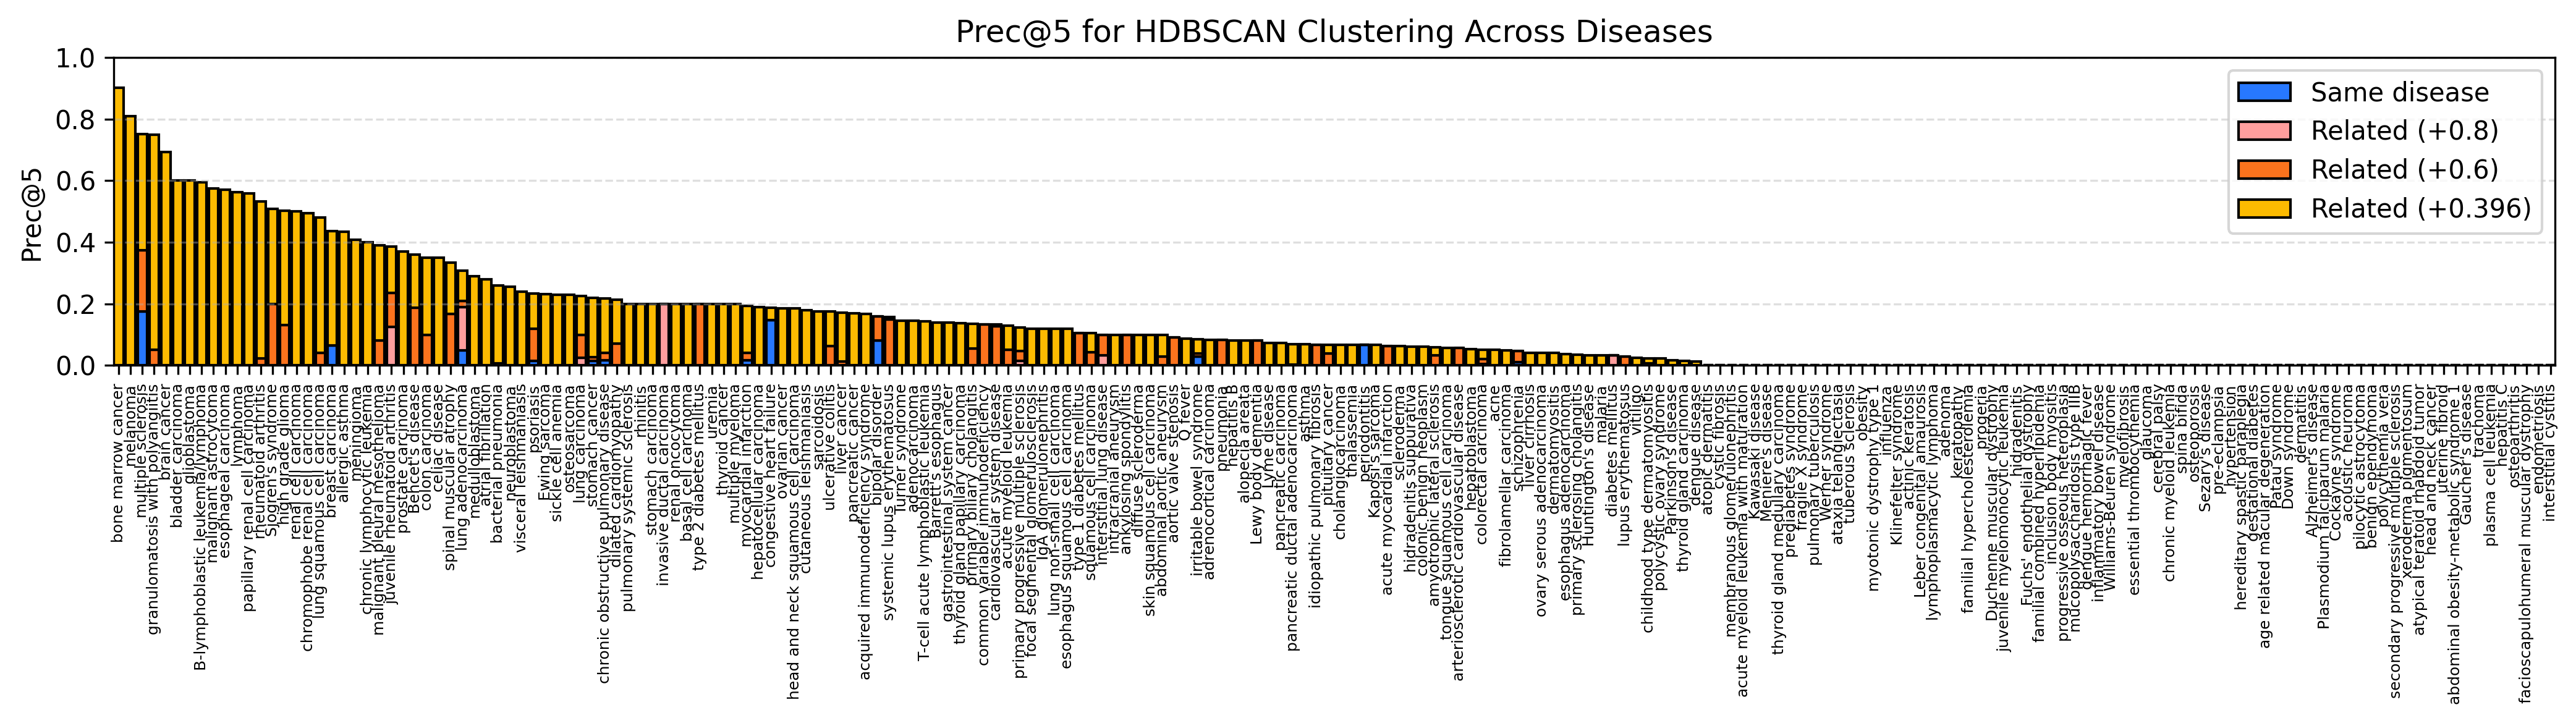

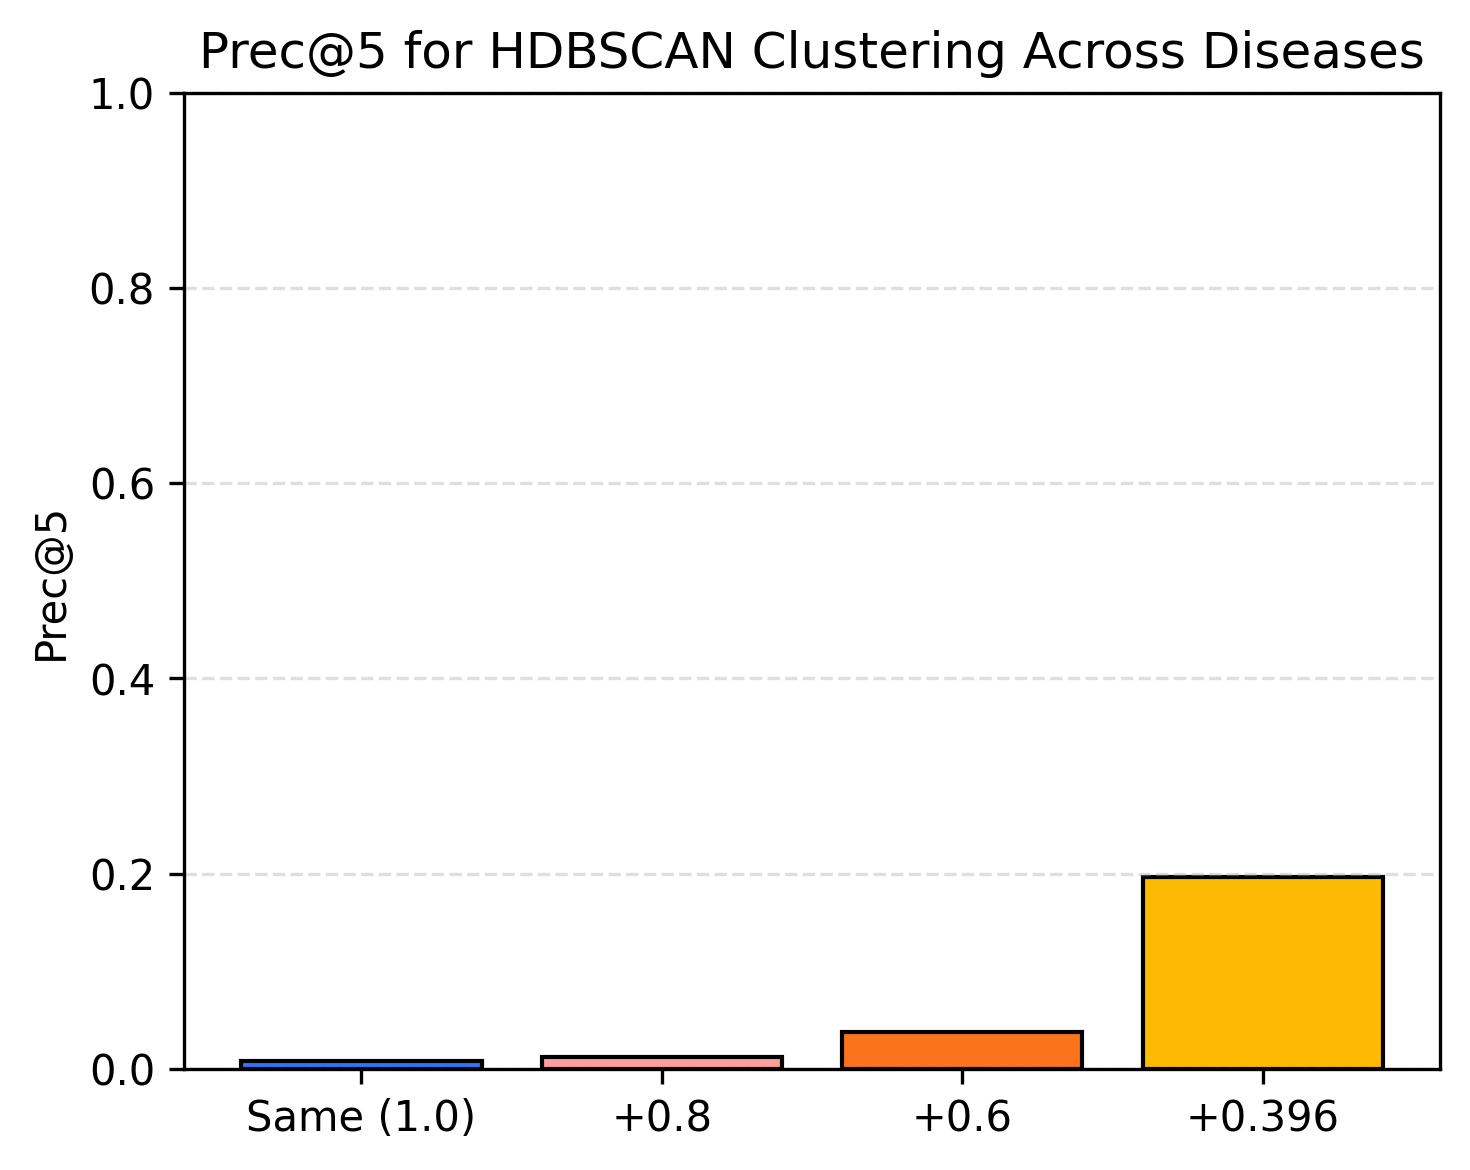

In [124]:
def plot_stacked_per_disease_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric="Prec@1",
    title:str=""
):
    """
    Compute stacked SAME/RELATED precision per disease using the similarity test_scores
    and plot diseases sorted by lowest relatedness tier (IC 0.396).
    """

    ICs = [1.0, 0.8, 0.6, 0.396]
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]

    diseases = list(dis_ord)
    N = len(diseases)

    # Matrix to store: (N_diseases × 4_IC_thresholds)
    perf = np.zeros((N, len(ICs)))

    for d_idx, disease in enumerate(diseases):

        # samples belonging to this disease
        mask = (df_test["doid_id"] == disease)

        if mask.sum() == 0:
            continue

        y_pred_d = test_scores[mask]

        for j, ic_thr in enumerate(ICs):

            y_true_d = ut.get_multilabel_y(
                df_test[mask],
                dis_ord,
                rel_map,
                thr_related=ic_thr
            )

            if metric == "Prec@1":
                val = get_precision_at_k(y_pred_d, y_true_d, k=1)
            
            elif metric == "Prec@5":
                val = get_precision_at_k(y_pred_d, y_true_d, k=5)

            else:
                raise ValueError("Only Prec@1 implemented for disease-level plot.")

            perf[d_idx, j] = val

    # ======================================================
    # 🔥 SORT DISEASES BY LOWEST RELATEDNESS TIER (IC = 0.396)
    # ======================================================
    lowest_tier = perf[:, -1]          # column for IC 0.396
    sort_idx = np.argsort(-lowest_tier)   # highest → lowest

    perf = perf[sort_idx]
    diseases_sorted = [diseases[i] for i in sort_idx]
    # ======================================================

    # ---- Plot ----
    N = len(diseases_sorted)
    x = np.arange(N)
    bottom = np.zeros(N)

    plt.figure(figsize=(14, 4), dpi=300)

    for j, ic_thr in enumerate(ICs):
        vals = perf[:, j]
        vals = vals - bottom
        label = "Same disease" if ic_thr == 1.0 else f"Related (+{ic_thr})"

        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[j],
            label=label,
            edgecolor="black",
            # linewidth=0.5
        )
        bottom += vals
    plt.margins(x=0)
    plt.xticks(x, [doid_to_term.get(d) for d in diseases_sorted], rotation=90, fontsize=6)
    plt.ylabel(metric)
    plt.title(title
    )
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_aggregate_precision_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric="Prec@1",
    title=""
):
    """
    Computes an aggregated precision score per IC threshold
    across all diseases and plots a single bar chart.
    """

    ICs = [1.0, 0.8, 0.6, 0.396]
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]

    # Vector to store aggregated scores per tier
    agg_vals = []

    for ic_thr in ICs:

        # True multilabel matrix under this IC definition
        y_true = ut.get_multilabel_y(
            df_test,
            dis_ord,
            rel_map,
            thr_related=ic_thr
        )

        # Metric calculation
        if metric == "Prec@1":
            val = get_precision_at_k(test_scores, y_true, k=1)

        elif metric == "Prec@5":
            val = get_precision_at_k(test_scores, y_true, k=5)

        else:
            raise ValueError("Only Prec@1 and Prec@5 are implemented.")

        agg_vals.append(val)

    # ---- Plot ----
    x = np.arange(len(ICs))

    plt.figure(figsize=(5, 4), dpi=300)
    plt.bar(
        x,
        agg_vals,
        color=colors,
        edgecolor="black"
    )

    labels = ["Same (1.0)", "+0.8", "+0.6", "+0.396"]
    plt.xticks(x, labels, rotation=0)
    plt.ylabel(metric)
    plt.ylim(0, 1.0)
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()



_metric = "Prec@5"

plot_stacked_per_disease_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric=_metric, 
    title=f"{_metric} for HDBSCAN Clustering Across Diseases")


plot_aggregate_precision_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric=_metric, 
    title=f"{_metric} for HDBSCAN Clustering Across Diseases")

In [128]:
best_k = 117
dis_ord = list(df_test["doid_id"].unique())

df_hd_best = df_hd_test_sort.query(f"k == @best_k")
_min_clust = df_hd_best["min_cluster_size"].values[0]
_min_samp = df_hd_best["min_samples"].values[0]

hdbscan_clust = HDBSCAN(min_cluster_size=_min_clust, min_samples=_min_samp, metric="precomputed")
hdbscan_clust = hdbscan_clust.fit(cosine_train)
hd_labels = hdbscan_clust.labels_
mask_noise = hd_labels == -1

_df_enrich = run_hypergeom_enrichment(hd_labels, df_train["doid_id"].astype(str).to_numpy())
_df_enrich = _df_enrich.copy()
_df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
_df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

clust_to_dis = {}
for cid in np.unique(_df_enrich_sig["cluster"]):
    if cid == -1:
        continue
    diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
    clust_to_dis[int(cid)] = diseases

clust_ord = np.sort(np.unique(preds))
clust_ord = clust_ord[clust_ord >= 0]
_centroids = get_clust_centroids(e_train, preds, clust_ord)

test_centr_sim = cosine_similarity(e_test, _centroids)

test_hd_scores = get_multilab_pred_fast(
    test_centr_sim,
    clust_to_dis,
    dis_ord,
    clust_ord
)

test_hd_scores = softmax(test_hd_scores, axis=1)

df_hd_1 = get_df_results_clean(df_hd_best, ["AUROC", "AP", "random"])
df_hd_2 = get_df_results_clean(df_hd_best, ["Prec@1", "Prec@3", "Prec@5"])

In [129]:
    df_k_test_i = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )

In [130]:
df_k_test_i

,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,1.000,0.492762,0.012895,0.004854,0.002991,0.002170,0.008341,0.002991,0.006511,0.041703,0.002669,0.003343,1.8337145873658278±0.9960206133919748
1,0.800,0.505582,0.021289,0.010990,0.005983,0.005044,0.011649,0.003417,0.007156,0.022391,0.005924,0.003857,1.8337145873658278±0.9960206133919748
2,0.600,0.516534,0.052947,0.037965,0.053493,0.034489,0.038149,0.006837,0.013612,0.026020,0.044750,0.009424,1.8337145873658278±0.9960206133919748
3,0.396,0.522924,0.184716,0.151883,0.202358,0.187225,0.196762,0.006785,0.017076,0.029477,0.192633,0.010717,1.8337145873658278±0.9960206133919748


In [88]:
df_hd_test

,k,min_cluster_size,min_samples,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,117,50,1,1.000,0.672926,0.110060,0.004854,0.126166,0.095548,0.069083,0.126166,0.286644,0.345416,0.133826,0.308816,2.7327115959880346±1.5736362260940846
1,117,50,1,0.800,0.675817,0.149353,0.010990,0.199894,0.174204,0.135879,0.082043,0.233283,0.298188,0.211807,0.249824,2.7327115959880346±1.5736362260940846
2,117,50,1,0.600,0.669033,0.197102,0.037965,0.336618,0.342014,0.298645,0.055032,0.160515,0.224401,0.359740,0.167530,2.7327115959880346±1.5736362260940846
3,117,50,1,0.396,0.634879,0.300759,0.151883,0.551821,0.549064,0.519901,0.021085,0.061404,0.093771,0.561115,0.059537,2.7327115959880346±1.5736362260940846
0,101,50,5,1.000,0.670316,0.099215,0.004854,0.101883,0.088158,0.062502,0.101883,0.264473,0.312511,0.117174,0.307760,2.751187752947387±1.8259753772286262
1,101,50,5,0.800,0.671055,0.149732,0.010990,0.195319,0.176315,0.139715,0.079755,0.235468,0.298625,0.207976,0.265001,2.751187752947387±1.8259753772286262
2,101,50,5,0.600,0.662419,0.189854,0.037965,0.341545,0.331574,0.286468,0.054977,0.151869,0.212047,0.354563,0.174065,2.751187752947387±1.8259753772286262
3,101,50,5,0.396,0.632835,0.295968,0.151883,0.574345,0.561030,0.525814,0.020677,0.060342,0.092152,0.567564,0.059120,2.751187752947387±1.8259753772286262
0,91,50,10,1.000,0.663292,0.096750,0.004854,0.105050,0.085694,0.064156,0.105050,0.257083,0.320781,0.119953,0.310048,2.76051381312687±1.9051528753319649
1,91,50,10,0.800,0.671136,0.146619,0.010990,0.190216,0.156021,0.123632,0.079535,0.215045,0.277515,0.197733,0.258637,2.76051381312687±1.9051528753319649


In [ ]:
from hdbscan import HDBSCAN

_min_cluster_sizes = [50]
_min_samples = [5]

for mcs in tqdm(_min_cluster_sizes):
    for ms in _min_samples:

        hdbscan_clust = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="precomputed")
        hdbscan_clust = hdbscan_clust.fit(cosine_train)
        preds = hdbscan_clust.labels_
        preds_no_noise = preds[preds >= 0]
        k = len(np.unique(preds_no_noise))

        if k <= 1:
            continue

        _results_i = evaluate_clusters(preds, df_train["doid_id"].values, e_train)
        _results_i.update({"k": k, "min_cluster_size": mcs, "min_samples": ms})
        results.append(_results_i)

        _df_enrich = run_hypergeom_enrichment(preds, df_train["doid_id"].astype(str).to_numpy())
        _df_enrich = _df_enrich.copy()
        _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
        _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

        clust_to_dis = {}
        for cid in np.unique(_df_enrich_sig["cluster"]):
            if cid == -1:
                continue
            diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
            clust_to_dis[int(cid)] = diseases

        clust_ord = np.sort(np.unique(preds))
        clust_ord = clust_ord[clust_ord >= 0]
        _centroids = get_clust_centroids(e_train, preds, clust_ord)

        test_centr_sim = cosine_similarity(e_test, _centroids)

        test_scores = get_multilab_pred_fast(
            test_centr_sim,
            clust_to_dis,
            dis_ord,
            clust_ord
        )

        test_scores = softmax(test_scores, axis=1)

        df_hd_test_i = eval_dis_clusters(
            test_scores,
            df_test,
            dis_ord,
            rel_map,
            eval_k=[1,3,5]
        )
        df_hd_test_i.insert(0, "k", k)
        df_hd_test_i.insert(1, "min_cluster_size", mcs)
        df_hd_test_i.insert(2, "min_samples", ms)

        if i == 0:
            df_hd_test = df_hd_test_i.copy()
            i += 1
        else:
            df_hd_test = pd.concat([df_hd_test, df_hd_test_i], axis=0)

        break
    break

  0%|          | 0/1 [00:30<?, ?it/s]


In [152]:
df_hd_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.126,0.287,0.345,0.200,0.174,0.136,0.337,0.342,0.299,0.552,0.549,0.520


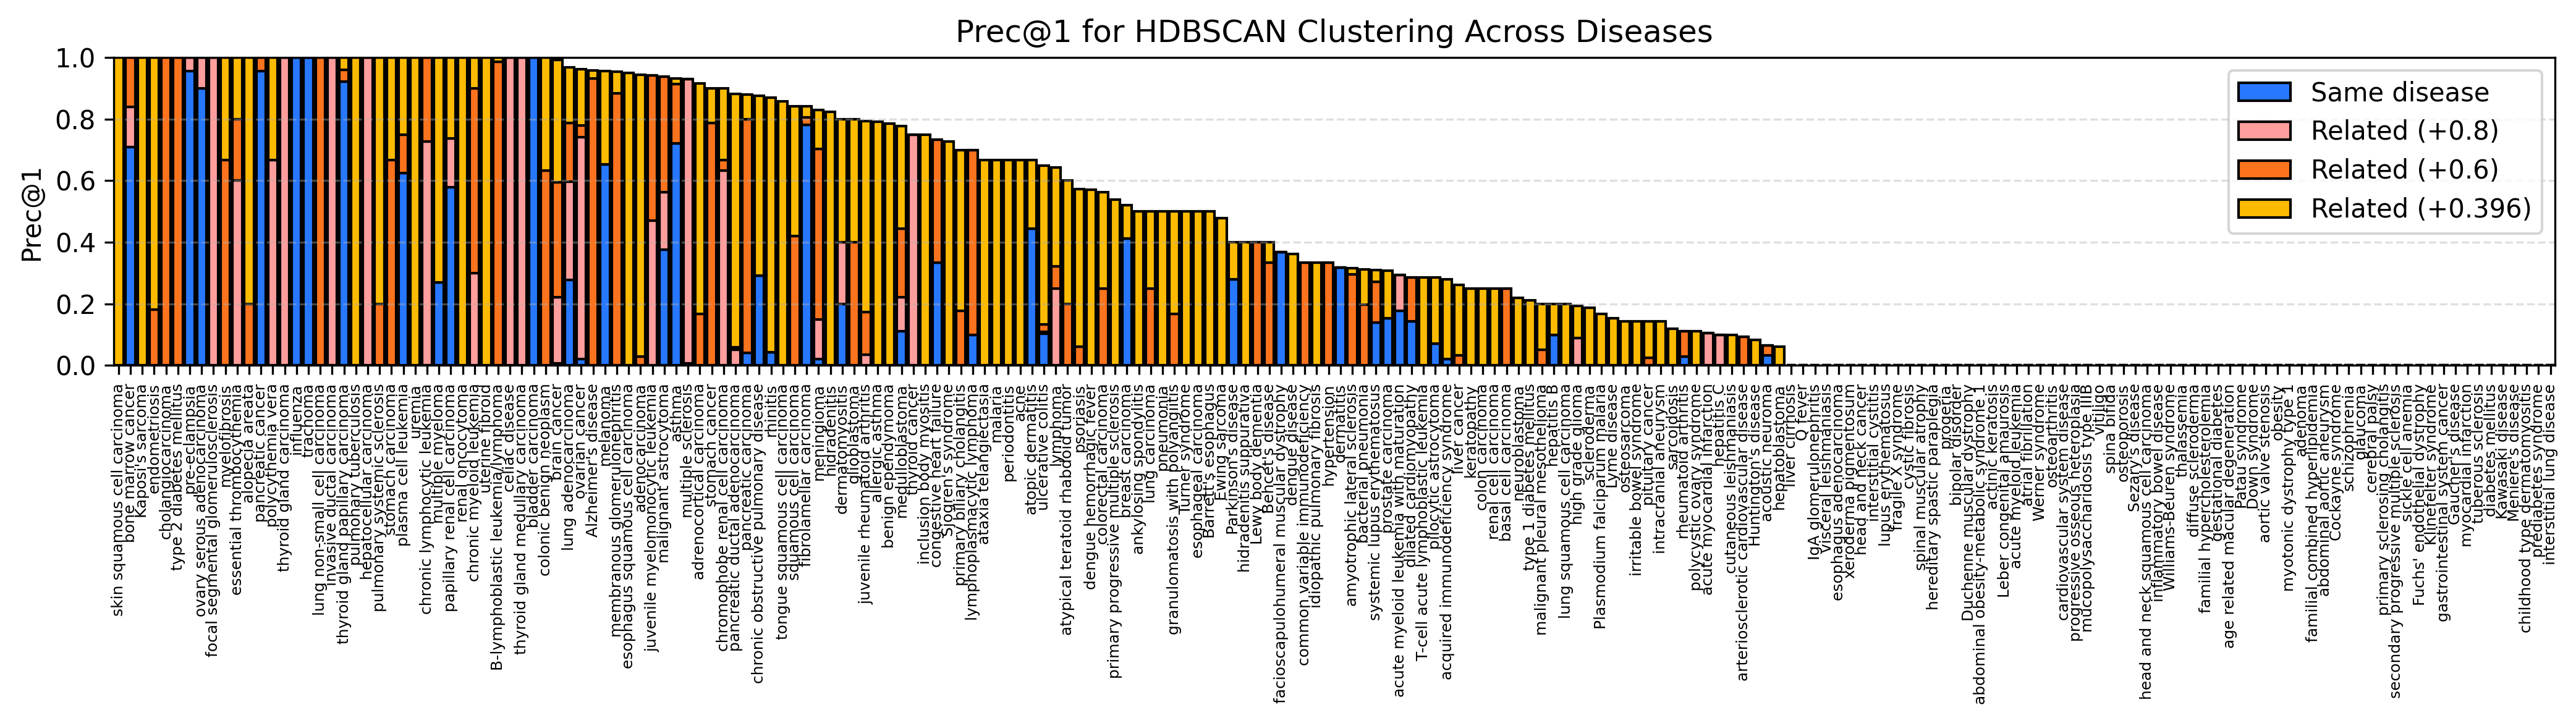

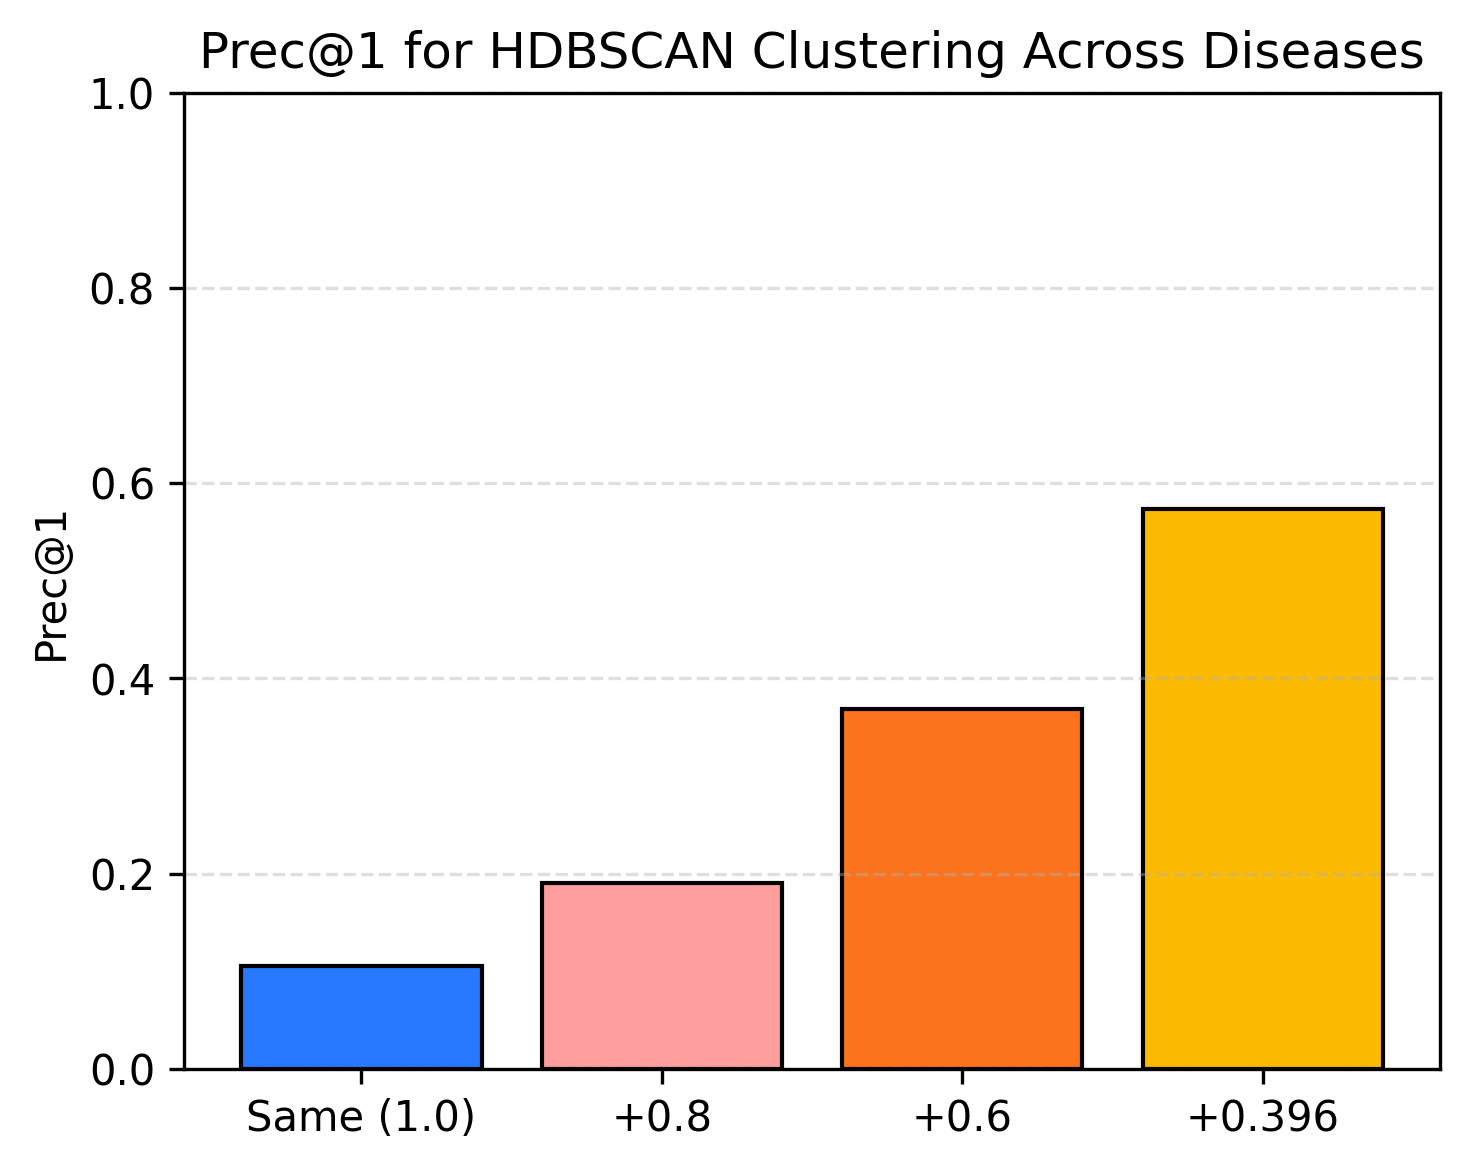

In [153]:
_metric = "Prec@1"
plot_stacked_per_disease_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric=_metric, 
    title=f"{_metric} for HDBSCAN Clustering Across Diseases")


plot_aggregate_precision_from_predictions(
    df_test,
    dis_ord,
    rel_map,
    test_scores,
    metric=_metric, 
    title=f"{_metric} for HDBSCAN Clustering Across Diseases")

In [45]:
import numpy as np

def cluster_purity(true_labels, cluster_labels):
    """
    Compute cluster purity given arrays of true labels and predicted cluster labels.
    Works for string labels (DOIDs), integers, anything hashable.
    """

    # Convert to numpy arrays
    true_labels = np.asarray(true_labels)
    cluster_labels = np.asarray(cluster_labels)

    # Convert true labels to integer IDs
    unique_true, true_int = np.unique(true_labels, return_inverse=True)

    # Convert cluster labels to integer IDs
    unique_clust, clust_int = np.unique(cluster_labels, return_inverse=True)

    total = len(true_labels)
    correct = 0

    # Loop over clusters
    for c in np.unique(clust_int):
        mask = (clust_int == c)
        if not np.any(mask):
            continue

        # Count frequency of true classes within this cluster
        counts = np.bincount(true_int[mask])
        correct += counts.max()

    return correct / total

mask_noise = hd_labels == -1
cluster_purity(df_train[~mask_noise]["doid_id"].to_numpy(), hd_labels[~mask_noise])

0.8443147379054888

In [51]:
len(mask_noise)

11823